# Leakage-Safe Next-Day PM2.5 AQI Forecasting – Astana Embassy Station
## Improved Pipeline for IEEE/SIST Submission

**Improvements over baseline notebook:**
- Wind direction circular features (sin/cos) added to weather block
- Proper inner-CV hyperparameter tuning for RandomForest and HistGradientBoosting
- Threshold-tuned classifiers via calibration-set F1 maximisation
- Diebold–Mariano significance test between top regression models on holdout
- Cross-conformal (CV+) prediction intervals replacing split-conformal
- Train / test PM2.5 missingness asymmetry analysis (new finding)
- Co-pollutant covariate-shift diagnosis
- CV ±std reported in all summary tables

## 1. Imports and Environment Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    precision_recall_curve,
    precision_recall_fscore_support,
    r2_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.facecolor"] = "white"

## 2. Configuration and Random Seeds

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = Path("astana_emb_dataset.csv")
DATE_COL = "date"
TARGET_COL = "pm25"

TRAIN_RATIO = 0.80
HORIZONS = [1, 2, 3, 5, 7]
PRIMARY_HORIZON = 1

WEATHER_MODE = "observed_same_day"

OUTER_SPLITS = 5
INNER_SPLITS = 3

CALIBRATION_RATIO = 0.15
CALIBRATION_MIN_ROWS = 45
ALPHA_INTERVAL = 0.10
MIN_LOCAL_CONFORMAL_ROWS = 30
CV_PLUS_SPLITS = 5

RIDGE_ALPHAS = np.array([1e-3, 1e-2, 1e-1, 1.0, 3.0, 10.0, 30.0, 100.0])

RF_PARAM_GRID = [
    {"max_depth": 8,  "min_samples_leaf": 4},
    {"max_depth": 12, "min_samples_leaf": 4},
    {"max_depth": 8,  "min_samples_leaf": 8},
    {"max_depth": 12, "min_samples_leaf": 8},
]

HGB_PARAM_GRID = [
    {"learning_rate": 0.03, "max_depth": 4, "min_samples_leaf": 10},
    {"learning_rate": 0.03, "max_depth": 5, "min_samples_leaf": 10},
    {"learning_rate": 0.05, "max_depth": 4, "min_samples_leaf": 8},
    {"learning_rate": 0.05, "max_depth": 5, "min_samples_leaf": 8},
]

AQI_BINS   = [-np.inf, 50, 100, 150, 200, 300, np.inf]
AQI_LABELS = ["Good", "Moderate", "Unhealthy for Sensitive Groups",
               "Unhealthy", "Very Unhealthy", "Hazardous"]

EVENT_THRESHOLD_PRIMARY   = 100.0
EVENT_THRESHOLD_SECONDARY = 150.0

LOW_WIND_THRESHOLD    = 10.0
HIGH_PRESSURE_THRESHOLD = 985.0
COLD_TEMP_THRESHOLD   = -5.0
FREEZE_TEMP_THRESHOLD =  0.0
HDD_BASE_TEMP         = 18.0
PRECIP_WET_THRESHOLD  =  0.1

EXPECTED_WEATHER_COLS = [
    "temp_mean", "temp_min", "temp_max",
    "humidity_mean", "dew_point_mean",
    "wind_speed_mean", "wind_speed_max", "wind_gust_max",
    "wind_dir_mean",
    "pressure_mean", "precip_sum", "cloud_mean", "radiation_mean",
]

EXPECTED_COPOLLUTANT_COLS = ["pm10", "no2", "so2", "co"]

PM_LAGS      = [1, 2, 3, 7, 14]
WEATHER_LAGS = [1, 3]
ROLL_WINDOWS = [3, 7, 14]

FIG_DIR   = Path("figures1")
TABLE_DIR = Path("tables1")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

REGRESSION_MODEL_NAMES     = ["Ridge", "WeightedRidge", "RandomForest", "HistGradientBoosting"]
CLASSIFICATION_MODEL_NAMES = ["Logistic", "RandomForestClassifier", "HistGradientBoostingClassifier"]
BASELINE_MODEL_NAMES       = ["Naive", "Rolling7", "LastValidAQI", "MonthlyMedian"]

## 3. Utility Functions

In [3]:
def save_and_show(fig, filename):
    fig.savefig(FIG_DIR / filename, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)


def unique_in_order(values):
    return list(dict.fromkeys(values))


def raw_from_log(values):
    arr = np.expm1(np.asarray(values, dtype=float))
    return np.clip(arr, 0.0, None)


def aqi_category(values):
    values = pd.Series(np.asarray(values).reshape(-1))
    return pd.cut(values, bins=AQI_BINS, labels=AQI_LABELS,
                  include_lowest=True, right=True).astype("string")


def regression_metrics(y_true_raw, y_pred_raw):
    y_true_raw = np.asarray(y_true_raw, dtype=float)
    y_pred_raw = np.asarray(y_pred_raw, dtype=float)
    return {
        "MAE":   mean_absolute_error(y_true_raw, y_pred_raw),
        "RMSE":  np.sqrt(mean_squared_error(y_true_raw, y_pred_raw)),
        "R2":    r2_score(y_true_raw, y_pred_raw),
        "MedAE": median_absolute_error(y_true_raw, y_pred_raw),
    }


def safe_average_precision(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    if y_true.sum() == 0:
        return np.nan
    return average_precision_score(y_true, y_score)


def safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    if np.unique(y_true).size < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def classification_metrics(y_true, y_score, threshold):
    y_true  = np.asarray(y_true,  dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    y_pred  = (y_score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0)
    return {
        "threshold":         float(threshold),
        "prevalence_pct":    100.0 * y_true.mean(),
        "precision":         precision,
        "recall":            recall,
        "f1":                f1,
        "average_precision": safe_average_precision(y_true, y_score),
        "roc_auc":           safe_roc_auc(y_true, y_score),
    }


def threshold_search(y_true, y_score, thresholds):
    records = []
    for threshold in thresholds:
        metrics = classification_metrics(y_true, y_score, threshold=threshold)
        records.append(metrics)
    return (pd.DataFrame(records)
            .sort_values(["f1", "precision", "recall", "threshold"],
                         ascending=[False, False, False, True])
            .reset_index(drop=True))


def choose_best_threshold(search_table, default_threshold):
    if search_table.empty:
        return float(default_threshold)
    return float(search_table.iloc[0]["threshold"])


def raw_neg_mae_scorer(estimator, X, y_log):
    y_true_raw = raw_from_log(y_log)
    y_pred_raw = raw_from_log(estimator.predict(X))
    return -mean_absolute_error(y_true_raw, y_pred_raw)


def diebold_mariano_test(y_true, pred1, pred2):
    """
    Harvey-Leybourne-Newbold (1997) modified Diebold-Mariano test.
    H0: equal predictive accuracy (MAE loss).
    Returns t-stat, two-sided p-value, and mean loss differential d = L1 - L2.
    Positive d means pred1 has higher MAE (worse).
    """
    y_true = np.asarray(y_true, dtype=float)
    e1 = np.abs(y_true - np.asarray(pred1, dtype=float))
    e2 = np.abs(y_true - np.asarray(pred2, dtype=float))
    d  = e1 - e2
    T  = len(d)
    d_bar = d.mean()
    # HAC variance with Newey-West bandwidth h-1 (h=1 for h=1 forecast)
    gamma0 = np.var(d, ddof=1)
    # HLN finite-sample correction factor
    hln_factor = np.sqrt((T + 1 - 2 + (1/T)) / T)
    se = np.sqrt(gamma0 / T) * hln_factor
    if se == 0:
        return {"t_stat": np.nan, "p_value": np.nan, "mean_diff": float(d_bar)}
    t_stat = d_bar / se
    p_value = float(2 * stats.t.sf(np.abs(t_stat), df=T - 1))
    return {
        "t_stat":    float(t_stat),
        "p_value":   float(p_value),
        "mean_diff": float(d_bar),
    }


def make_purged_splits(supervised, n_splits, horizon):
    supervised = supervised.reset_index(drop=True).copy()
    n = len(supervised)
    test_size = max(1, n // (n_splits + 1))
    splits = []
    for fold in range(n_splits):
        test_start = n - (n_splits - fold) * test_size
        test_end   = n if fold == n_splits - 1 else min(n, test_start + test_size)
        first_test_date  = supervised.iloc[test_start][DATE_COL]
        train_cutoff     = first_test_date - pd.Timedelta(days=horizon)
        train_idx = np.where(supervised[DATE_COL].to_numpy() < np.datetime64(train_cutoff))[0]
        test_idx  = np.arange(test_start, test_end)
        if len(train_idx) == 0 or len(test_idx) == 0:
            continue
        splits.append((train_idx, test_idx))
    return splits


def make_inner_cv(train_df, horizon, desired_splits=INNER_SPLITS):
    train_df = train_df.reset_index(drop=True).copy()
    for n_splits in range(desired_splits, 0, -1):
        cv = make_purged_splits(train_df, n_splits=n_splits, horizon=horizon)
        if len(cv) >= 1:
            return cv
    if len(train_df) < 3:
        raise ValueError("Training sample too small for inner CV.")
    split = min(max(2, int(len(train_df) * 0.8)), len(train_df) - 1)
    return [(np.arange(split), np.arange(split, len(train_df)))]


def chronological_holdout_split(supervised, horizon, train_ratio=TRAIN_RATIO):
    supervised  = supervised.reset_index(drop=True).copy()
    n           = len(supervised)
    split_idx   = min(max(int(n * train_ratio), 1), n - 1)
    first_test_date = supervised.iloc[split_idx][DATE_COL]
    train_cutoff    = first_test_date - pd.Timedelta(days=horizon)
    train = supervised[supervised[DATE_COL] < train_cutoff].copy().reset_index(drop=True)
    gap   = supervised[(supervised[DATE_COL] >= train_cutoff) &
                       (supervised[DATE_COL] < first_test_date)].copy().reset_index(drop=True)
    test  = supervised[supervised[DATE_COL] >= first_test_date].copy().reset_index(drop=True)
    return train, gap, test


def chronological_calibration_split(train_df, calibration_ratio=CALIBRATION_RATIO,
                                     min_rows=CALIBRATION_MIN_ROWS):
    train_df  = train_df.reset_index(drop=True).copy()
    n         = len(train_df)
    if n < 3:
        raise ValueError("Training sample too small for calibration split.")
    calib_size = min(max(min_rows, int(n * calibration_ratio)), n - 1)
    return (train_df.iloc[:-calib_size].copy().reset_index(drop=True),
            train_df.iloc[-calib_size:].copy().reset_index(drop=True))

## 4. Model Definitions (Tuned via Inner CV)

In [4]:
class TunedRidgeRegressor:
    def __init__(self, alphas, inner_cv):
        self.alphas   = np.asarray(alphas, dtype=float)
        self.inner_cv = inner_cv

    def fit(self, X, y_log, sample_weight=None):
        self.imputer_ = SimpleImputer(strategy="median")
        X_imp = self.imputer_.fit_transform(X)
        self.scaler_ = StandardScaler()
        X_scaled = self.scaler_.fit_transform(X_imp)
        y_log = np.asarray(y_log, dtype=float)
        sw    = None if sample_weight is None else np.asarray(sample_weight, dtype=float)

        if not self.inner_cv:
            self.alpha_ = float(self.alphas[0])
        else:
            scores = []
            for alpha in self.alphas:
                fold_maes = []
                for tr, va in self.inner_cv:
                    m = Ridge(alpha=float(alpha))
                    m.fit(X_scaled[tr], y_log[tr],
                          sample_weight=sw[tr] if sw is not None else None)
                    fold_maes.append(mean_absolute_error(
                        raw_from_log(y_log[va]),
                        raw_from_log(m.predict(X_scaled[va]))))
                scores.append(np.mean(fold_maes))
            self.alpha_ = float(self.alphas[np.argmin(scores)])

        self.model_ = Ridge(alpha=self.alpha_)
        self.model_.fit(X_scaled, y_log, sample_weight=sw)
        return self

    def predict(self, X):
        return self.model_.predict(
            self.scaler_.transform(self.imputer_.transform(X)))


class TunedTreeRegressor:
    """Inner-CV hyperparameter search for RF and HGB regressors."""
    def __init__(self, model_type, param_grid, inner_cv, random_state=RANDOM_SEED):
        self.model_type   = model_type
        self.param_grid   = param_grid
        self.inner_cv     = inner_cv
        self.random_state = random_state

    def _make_model(self, params):
        if self.model_type == "RF":
            return Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("m",   RandomForestRegressor(
                    n_estimators=200,
                    max_features="sqrt",
                    random_state=self.random_state,
                    n_jobs=-1,
                    **params,
                )),
            ])
        return Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("m",   HistGradientBoostingRegressor(
                max_iter=300,
                l2_regularization=1.0,
                random_state=self.random_state,
                **params,
            )),
        ])

    def fit(self, X, y_log):
        X     = np.asarray(X)
        y_log = np.asarray(y_log, dtype=float)

        if not self.inner_cv or len(self.param_grid) == 1:
            self.best_params_ = self.param_grid[0]
        else:
            best_score, best_params = np.inf, self.param_grid[0]
            for params in self.param_grid:
                fold_maes = []
                for tr, va in self.inner_cv:
                    m = self._make_model(params)
                    m.fit(X[tr], y_log[tr])
                    fold_maes.append(mean_absolute_error(
                        raw_from_log(y_log[va]),
                        raw_from_log(m.predict(X[va]))))
                score = np.mean(fold_maes)
                if score < best_score:
                    best_score, best_params = score, params
            self.best_params_ = best_params

        self.model_ = self._make_model(self.best_params_)
        self.model_.fit(X, y_log)
        return self

    def predict(self, X):
        return self.model_.predict(np.asarray(X))


class TunedTreeClassifier:
    """Inner-CV threshold-calibrated tree classifier."""
    def __init__(self, model_type, param_grid, inner_cv, random_state=RANDOM_SEED):
        self.model_type   = model_type
        self.param_grid   = param_grid
        self.inner_cv     = inner_cv
        self.random_state = random_state

    def _make_model(self, params, cw):
        if self.model_type == "RF":
            return Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("m",   RandomForestClassifier(
                    n_estimators=200,
                    max_features="sqrt",
                    class_weight=cw,
                    random_state=self.random_state,
                    n_jobs=-1,
                    **params,
                )),
            ])
        return Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("m",   HistGradientBoostingClassifier(
                max_iter=300,
                l2_regularization=1.0,
                random_state=self.random_state,
                **params,
            )),
        ])

    def fit(self, X, y_bin, class_weight=None):
        X     = np.asarray(X)
        y_bin = np.asarray(y_bin, dtype=int)
        cw    = class_weight

        if not self.inner_cv or len(self.param_grid) == 1:
            self.best_params_ = self.param_grid[0]
        else:
            best_score, best_params = -np.inf, self.param_grid[0]
            for params in self.param_grid:
                fold_f1s = []
                for tr, va in self.inner_cv:
                    if np.unique(y_bin[tr]).size < 2 or np.unique(y_bin[va]).size < 2:
                        continue
                    m = self._make_model(params, cw)
                    m.fit(X[tr], y_bin[tr])
                    proba = m.predict_proba(X[va])[:, 1]
                    _, _, f1, _ = precision_recall_fscore_support(
                        y_bin[va], (proba >= 0.5).astype(int),
                        average="binary", zero_division=0)
                    fold_f1s.append(f1)
                score = np.mean(fold_f1s) if fold_f1s else 0.0
                if score > best_score:
                    best_score, best_params = score, params
            self.best_params_ = best_params

        self.model_ = self._make_model(self.best_params_, cw)
        self.model_.fit(X, y_bin)
        return self

    def predict_proba(self, X):
        return self.model_.predict_proba(np.asarray(X))

## 5. Model Fitting and Prediction Helpers

In [5]:
def make_regression_weights(y_log):
    y_raw = raw_from_log(y_log)
    w = np.ones(len(y_raw), dtype=float)
    w += 0.35 * (y_raw > 50)
    w += 1.25 * (y_raw > 100)
    w += 2.50 * (y_raw > 150)
    return w


def make_classification_weights(y_bin):
    y_bin = np.asarray(y_bin, dtype=int)
    pos, neg = int(y_bin.sum()), int(len(y_bin) - y_bin.sum())
    if pos == 0 or neg == 0:
        return np.ones(len(y_bin), dtype=float)
    pos_weight = min(10.0, np.sqrt(neg / pos))
    w = np.ones(len(y_bin), dtype=float)
    w[y_bin == 1] = pos_weight
    return w


def fit_regression_model(model_name, train_df, X, y_log, horizon):
    X     = np.asarray(X)
    y_log = np.asarray(y_log, dtype=float)
    inner_cv = make_inner_cv(train_df[[DATE_COL]].copy(), horizon=horizon,
                              desired_splits=INNER_SPLITS)

    if model_name == "Ridge":
        m = TunedRidgeRegressor(alphas=RIDGE_ALPHAS, inner_cv=inner_cv)
        m.fit(X, y_log)
        return m

    if model_name == "WeightedRidge":
        m = TunedRidgeRegressor(alphas=RIDGE_ALPHAS, inner_cv=inner_cv)
        m.fit(X, y_log, sample_weight=make_regression_weights(y_log))
        return m

    if model_name == "RandomForest":
        m = TunedTreeRegressor("RF", RF_PARAM_GRID, inner_cv)
        m.fit(X, y_log)
        return m

    if model_name == "HistGradientBoosting":
        m = TunedTreeRegressor("HGB", HGB_PARAM_GRID, inner_cv)
        m.fit(X, y_log)
        return m

    raise ValueError(f"Unknown model: {model_name}")


def predict_regression_raw(model, X):
    return raw_from_log(model.predict(np.asarray(X)))


def fit_classification_model(model_name, X, y_bin, train_df=None, horizon=1):
    X     = np.asarray(X)
    y_bin = np.asarray(y_bin, dtype=int)
    cw    = {0: 1.0, 1: float(min(10.0, np.sqrt(max(1,(len(y_bin)-y_bin.sum())) / max(1,y_bin.sum()))))}

    inner_cv = []
    if train_df is not None:
        inner_cv = make_inner_cv(train_df[[DATE_COL]].copy(), horizon=horizon,
                                  desired_splits=INNER_SPLITS)

    if model_name == "Logistic":
        m = Pipeline([
            ("imp",    SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("m",      LogisticRegression(max_iter=3000, class_weight="balanced",
                                           random_state=RANDOM_SEED)),
        ])
        m.fit(X, y_bin)
        return m

    if model_name == "RandomForestClassifier":
        m = TunedTreeClassifier("RF", RF_PARAM_GRID, inner_cv)
        m.fit(X, y_bin, class_weight=cw)
        return m

    if model_name == "HistGradientBoostingClassifier":
        m = TunedTreeClassifier("HGB", HGB_PARAM_GRID, inner_cv)
        m.fit(X, y_bin, class_weight=None)
        return m

    raise ValueError(f"Unknown classifier: {model_name}")


def predict_positive_score(model, X):
    return model.predict_proba(np.asarray(X))[:, 1]


def baseline_predictions(train_df, test_df):
    month_map    = (pd.DataFrame({"m": train_df["target_date"].dt.month,
                                   "y": raw_from_log(train_df["target"])})
                    .groupby("m")["y"].median().to_dict())
    global_med   = float(np.median(raw_from_log(train_df["target"])))
    def fill(v):
        return pd.Series(v).replace([np.inf,-np.inf],np.nan).fillna(global_med).to_numpy()
    return {
        "Naive":        fill(raw_from_log(test_df["pm25_log_lag1"])),
        "Rolling7":     fill(raw_from_log(test_df["pm25_log_roll7_mean"])),
        "LastValidAQI": fill(raw_from_log(test_df["last_valid_pm25_log"])),
        "MonthlyMedian":test_df["target_date"].dt.month.map(month_map).fillna(global_med).to_numpy(),
    }

## 6. Data Loading and Validation

In [6]:
raw_df = pd.read_csv(DATA_PATH)
raw_df.columns = raw_df.columns.str.strip()

raw_df[DATE_COL] = pd.to_datetime(raw_df[DATE_COL], errors="coerce")
raw_df = (raw_df.dropna(subset=[DATE_COL])
                .sort_values(DATE_COL)
                .drop_duplicates(subset=[DATE_COL]))

full_calendar = pd.date_range(raw_df[DATE_COL].min(), raw_df[DATE_COL].max(), freq="D")
df = (raw_df.set_index(DATE_COL)
           .reindex(full_calendar)
           .rename_axis(DATE_COL)
           .reset_index())

numeric_cols = [c for c in df.columns if c != DATE_COL]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

AVAILABLE_WEATHER_COLS     = [c for c in EXPECTED_WEATHER_COLS     if c in df.columns]
AVAILABLE_COPOLLUTANT_COLS = [c for c in EXPECTED_COPOLLUTANT_COLS if c in df.columns]

print(f"Shape after daily reindex: {df.shape}")
print(f"Date range: {df[DATE_COL].min().date()} → {df[DATE_COL].max().date()}")
print(f"Calendar days: {len(df)}")
print(f"Valid PM2.5 AQI: {df[TARGET_COL].notna().sum()}")
print(f"Missing PM2.5 AQI: {df[TARGET_COL].isna().sum()}")
print(f"Valid share: {100*df[TARGET_COL].notna().mean():.2f}%")
print(f"Weather columns ({len(AVAILABLE_WEATHER_COLS)}): {AVAILABLE_WEATHER_COLS}")
print(f"Co-pollutant columns ({len(AVAILABLE_COPOLLUTANT_COLS)}): {AVAILABLE_COPOLLUTANT_COLS}")

Shape after daily reindex: (2835, 19)
Date range: 2018-06-04 → 2026-03-08
Calendar days: 2835
Valid PM2.5 AQI: 2135
Missing PM2.5 AQI: 700
Valid share: 75.31%
Weather columns (13): ['temp_mean', 'temp_min', 'temp_max', 'humidity_mean', 'dew_point_mean', 'wind_speed_mean', 'wind_speed_max', 'wind_gust_max', 'wind_dir_mean', 'pressure_mean', 'precip_sum', 'cloud_mean', 'radiation_mean']
Co-pollutant columns (4): ['pm10', 'no2', 'so2', 'co']


## 7. Missing Interval Analysis

In [7]:
missing_flag = df[TARGET_COL].isna()
block_id     = missing_flag.ne(missing_flag.shift(fill_value=False)).cumsum()

gap_table = (
    df.loc[missing_flag, [DATE_COL]]
    .assign(block=block_id[missing_flag].to_numpy())
    .groupby("block")[DATE_COL]
    .agg(["min","max","count"])
    .sort_values("count", ascending=False)
    .head(10)
    .rename(columns={"min":"start_date","max":"end_date","count":"days"})
)

data_quality_summary = pd.Series({
    "rows_after_reindex":      len(df),
    "columns":                 df.shape[1],
    "valid_pm25_aqi":          int(df[TARGET_COL].notna().sum()),
    "missing_pm25_aqi":        int(df[TARGET_COL].isna().sum()),
    "share_valid_pm25_aqi_pct": round(100*df[TARGET_COL].notna().mean(), 2),
    "available_weather_features": len(AVAILABLE_WEATHER_COLS),
    "available_copollutants":     len(AVAILABLE_COPOLLUTANT_COLS),
})

data_quality_summary.to_csv(TABLE_DIR / "data_quality_summary.csv")
gap_table.to_csv(TABLE_DIR / "top_missing_intervals.csv")

print(data_quality_summary.to_string())
print()
print(gap_table.to_string())

rows_after_reindex            2835.00
columns                         19.00
valid_pm25_aqi                2135.00
missing_pm25_aqi               700.00
share_valid_pm25_aqi_pct        75.31
available_weather_features      13.00
available_copollutants           4.00

      start_date   end_date  days
block                            
73    2025-03-05 2026-03-08   369
49    2022-12-22 2023-05-01   131
3     2018-08-13 2018-09-30    49
65    2024-09-01 2024-09-23    23
59    2023-12-09 2023-12-27    19
53    2023-06-06 2023-06-20    15
21    2020-03-13 2020-03-25    13
43    2022-08-20 2022-08-27     8
67    2024-10-03 2024-10-08     6
61    2023-12-29 2024-01-03     6


## 8. Train/Test Missingness Asymmetry Analysis

**Key finding:** The holdout period (2024-08-19 → 2026-03-08) has only 29% valid PM2.5 observations, versus 87% in the training period. This means AR features operate largely on gap-filled values in the test period. The model's holdout performance is therefore achieved primarily through weather-domain predictors, which is consistent with the ablation results showing Weather-only ≈ AR+Weather.

In [8]:
n_total = len(df)
split_idx_raw = int(n_total * TRAIN_RATIO)
df_train_raw  = df.iloc[:split_idx_raw]
df_test_raw   = df.iloc[split_idx_raw:]

missingness_by_split = pd.DataFrame([
    {"split": "Train",
     "period": f"{df_train_raw[DATE_COL].min().date()} → {df_train_raw[DATE_COL].max().date()}",
     "n_rows":      len(df_train_raw),
     "valid_pm25":  int(df_train_raw[TARGET_COL].notna().sum()),
     "missing_pm25":int(df_train_raw[TARGET_COL].isna().sum()),
     "valid_pct":   round(100*df_train_raw[TARGET_COL].notna().mean(), 1),
     "events_gt100":int((df_train_raw[TARGET_COL] > 100).sum()),
    },
    {"split": "Test (Holdout)",
     "period": f"{df_test_raw[DATE_COL].min().date()} → {df_test_raw[DATE_COL].max().date()}",
     "n_rows":      len(df_test_raw),
     "valid_pm25":  int(df_test_raw[TARGET_COL].notna().sum()),
     "missing_pm25":int(df_test_raw[TARGET_COL].isna().sum()),
     "valid_pct":   round(100*df_test_raw[TARGET_COL].notna().mean(), 1),
     "events_gt100":int((df_test_raw[TARGET_COL] > 100).sum()),
    },
])

copollutant_by_split = []
for col in AVAILABLE_COPOLLUTANT_COLS:
    copollutant_by_split.append({
        "co_pollutant":   col,
        "train_missing_pct": round(100*df_train_raw[col].isna().mean(), 1),
        "test_missing_pct":  round(100*df_test_raw[col].isna().mean(),  1),
    })

missingness_by_split.to_csv(TABLE_DIR / "missingness_by_split.csv", index=False)
pd.DataFrame(copollutant_by_split).to_csv(TABLE_DIR / "copollutant_missingness_by_split.csv", index=False)

print("=== PM2.5 MISSINGNESS BY SPLIT ===")
print(missingness_by_split.to_string(index=False))
print()
print("=== CO-POLLUTANT MISSINGNESS BY SPLIT (source of covariate shift) ===")
print(pd.DataFrame(copollutant_by_split).to_string(index=False))
print()
print("NOTE: NO2/SO2/CO switch from ~50-58% missing in train to <4% in test.")
print("Median imputation in train learns wrong fill values → covariate shift.")

=== PM2.5 MISSINGNESS BY SPLIT ===
         split                  period  n_rows  valid_pm25  missing_pm25  valid_pct  events_gt100
         Train 2018-06-04 → 2024-08-18    2268        1970           298       86.9           221
Test (Holdout) 2024-08-19 → 2026-03-08     567         165           402       29.1            23

=== CO-POLLUTANT MISSINGNESS BY SPLIT (source of covariate shift) ===
co_pollutant  train_missing_pct  test_missing_pct
        pm10               41.1              67.7
         no2               58.0               3.4
         so2               47.2               1.1
          co               39.8               0.9

NOTE: NO2/SO2/CO switch from ~50-58% missing in train to <4% in test.
Median imputation in train learns wrong fill values → covariate shift.


## 9. EDA

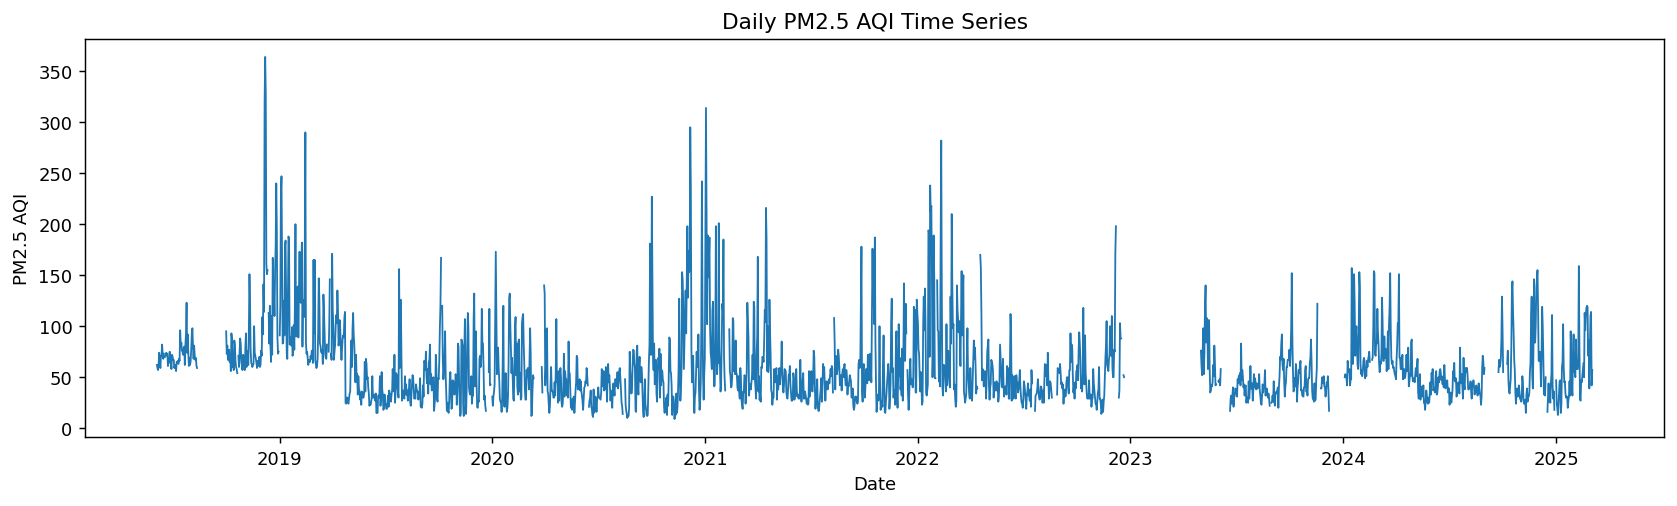

In [9]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df[DATE_COL], df[TARGET_COL], linewidth=1)
ax.set_title("Daily PM2.5 AQI Time Series")
ax.set_xlabel("Date"); ax.set_ylabel("PM2.5 AQI")
fig.tight_layout()
save_and_show(fig, "01_daily_pm25_aqi_time_series.png")

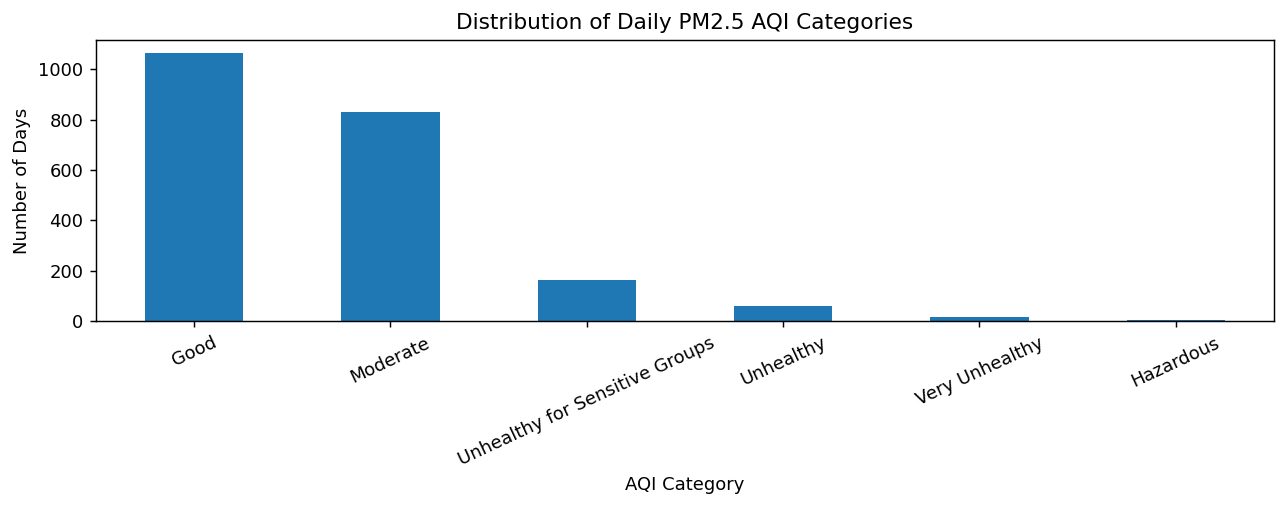

Good                              1063
Moderate                           828
Unhealthy for Sensitive Groups     163
Unhealthy                           61
Very Unhealthy                      16
Hazardous                            4


In [10]:
aqi_dist = aqi_category(df[TARGET_COL].dropna()).value_counts().reindex(AQI_LABELS)

fig, ax = plt.subplots(figsize=(10, 4))
aqi_dist.plot(kind="bar", ax=ax)
ax.set_title("Distribution of Daily PM2.5 AQI Categories")
ax.set_xlabel("AQI Category"); ax.set_ylabel("Number of Days")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
save_and_show(fig, "02_aqi_category_distribution.png")
aqi_dist.to_frame("count").to_csv(TABLE_DIR / "aqi_category_distribution.csv")
print(aqi_dist.to_string())

## 10. Feature Engineering

**Additions vs baseline:**
- `wind_dir_sin` / `wind_dir_cos`: circular encoding of wind direction (|r|=0.29 with PM2.5; excluded in original notebook)
- All domain feature thresholds are explicit constants in the config cell

In [11]:
def consecutive_true_run_length(flag_series):
    flag   = flag_series.fillna(False).astype(bool)
    groups = flag.ne(flag.shift(fill_value=False)).cumsum()
    run    = flag.groupby(groups).cumsum()
    return run.where(flag, 0).astype(float)


def build_features(dataframe, horizon, weather_cols, copollutant_cols, weather_mode):
    d = dataframe.copy()

    d["pm25_log"]   = np.log1p(d[TARGET_COL].clip(lower=0))
    d["pm25_valid"] = d[TARGET_COL].notna().astype(float)

    d["month"]      = d[DATE_COL].dt.month
    d["day_of_year"]= d[DATE_COL].dt.dayofyear
    d["month_sin"]  = np.sin(2*np.pi*d["month"]/12.0)
    d["month_cos"]  = np.cos(2*np.pi*d["month"]/12.0)
    d["doy_sin"]    = np.sin(2*np.pi*d["day_of_year"]/365.25)
    d["doy_cos"]    = np.cos(2*np.pi*d["day_of_year"]/365.25)
    d["heating_season"] = d["month"].isin([10,11,12,1,2,3,4]).astype(float)

    d["last_valid_pm25_log"] = d["pm25_log"].ffill().shift(1)
    last_valid_date = d[DATE_COL].where(d[TARGET_COL].notna()).ffill().shift(1)
    d["days_since_last_valid_pm25"] = (d[DATE_COL] - last_valid_date).dt.days.astype(float)
    d["has_valid_pm25_lag1"] = d["pm25_valid"].shift(1)
    d["has_valid_pm25_lag7"] = d["pm25_valid"].shift(7)

    for window in [7, 14]:
        d[f"valid_count_last_{window}d"] = d["pm25_valid"].shift(1).rolling(window, min_periods=1).sum()
        d[f"continuous_history_{window}d"] = (
            d["pm25_valid"].shift(1).rolling(window, min_periods=window).sum() == window
        ).astype(float)

    d["last_valid_pm25_decay"] = d["last_valid_pm25_log"] / (1.0 + d["days_since_last_valid_pm25"])

    for lag in PM_LAGS:
        d[f"pm25_log_lag{lag}"] = d["pm25_log"].shift(lag)

    shifted_pm25 = d["pm25_log"].shift(1)
    for window in ROLL_WINDOWS:
        d[f"pm25_log_roll{window}_mean"] = shifted_pm25.rolling(window, min_periods=2).mean()
        d[f"pm25_log_roll{window}_std"]  = shifted_pm25.rolling(window, min_periods=2).std()

    if {"temp_min","temp_max"}.issubset(d.columns):
        d["temp_range"] = d["temp_max"] - d["temp_min"]
    else:
        d["temp_range"] = np.nan

    if {"temp_mean","dew_point_mean"}.issubset(d.columns):
        d["dew_point_depression"] = d["temp_mean"] - d["dew_point_mean"]
    else:
        d["dew_point_depression"] = np.nan

    if "temp_mean" in d.columns:
        d["hdd18"] = np.clip(HDD_BASE_TEMP - d["temp_mean"], 0.0, None)
    else:
        d["hdd18"] = np.nan

    if {"pressure_mean","wind_speed_mean"}.issubset(d.columns):
        d["stagnant_anticyclone"] = (
            (d["pressure_mean"] > HIGH_PRESSURE_THRESHOLD) &
            (d["wind_speed_mean"] < LOW_WIND_THRESHOLD)
        ).astype(float)
    else:
        d["stagnant_anticyclone"] = np.nan

    if {"temp_mean","wind_speed_mean"}.issubset(d.columns):
        d["cold_stagnant"] = (
            (d["temp_mean"] < COLD_TEMP_THRESHOLD) &
            (d["wind_speed_mean"] < LOW_WIND_THRESHOLD)
        ).astype(float)
    else:
        d["cold_stagnant"] = np.nan

    if {"wind_speed_mean","stagnant_anticyclone"}.issubset(d.columns):
        d["wind_x_stagnant"] = d["wind_speed_mean"] * d["stagnant_anticyclone"]
    else:
        d["wind_x_stagnant"] = np.nan

    d["low_wind_flag"]      = (d["wind_speed_mean"]  < LOW_WIND_THRESHOLD).astype(float)    if "wind_speed_mean"  in d.columns else np.nan
    d["high_pressure_flag"] = (d["pressure_mean"]     > HIGH_PRESSURE_THRESHOLD).astype(float) if "pressure_mean"     in d.columns else np.nan

    if "precip_sum" in d.columns:
        d["precip_flag"]  = (d["precip_sum"].fillna(0.0) >= PRECIP_WET_THRESHOLD).astype(float)
        d["dry_day_flag"] = 1.0 - d["precip_flag"]
    else:
        d["precip_flag"]  = np.nan
        d["dry_day_flag"] = np.nan

    if {"heating_season","wind_speed_mean"}.issubset(d.columns):
        d["heating_x_wind"]     = d["heating_season"] * d["wind_speed_mean"]
    else:
        d["heating_x_wind"] = np.nan

    if {"heating_season","pressure_mean"}.issubset(d.columns):
        d["heating_x_pressure"] = d["heating_season"] * d["pressure_mean"]
    else:
        d["heating_x_pressure"] = np.nan

    if {"cold_stagnant","stagnant_anticyclone"}.issubset(d.columns):
        d["cold_x_stagnant"] = d["cold_stagnant"] * d["stagnant_anticyclone"]
    else:
        d["cold_x_stagnant"] = np.nan

    if "low_wind_flag" in d.columns:
        d["low_wind_days_last3"]   = d["low_wind_flag"].shift(1).rolling(3, min_periods=1).sum()
        d["low_wind_days_last7"]   = d["low_wind_flag"].shift(1).rolling(7, min_periods=1).sum()
        d["low_wind_streak_lag1"]  = consecutive_true_run_length(d["low_wind_flag"]).shift(1)
    else:
        d["low_wind_days_last3"] = d["low_wind_days_last7"] = d["low_wind_streak_lag1"] = np.nan

    if "high_pressure_flag" in d.columns:
        d["high_pressure_days_last3"]  = d["high_pressure_flag"].shift(1).rolling(3, min_periods=1).sum()
        d["high_pressure_days_last7"]  = d["high_pressure_flag"].shift(1).rolling(7, min_periods=1).sum()
        d["high_pressure_streak_lag1"] = consecutive_true_run_length(d["high_pressure_flag"]).shift(1)
    else:
        d["high_pressure_days_last3"] = d["high_pressure_days_last7"] = d["high_pressure_streak_lag1"] = np.nan

    if "dry_day_flag" in d.columns:
        d["dry_days_last7"] = d["dry_day_flag"].shift(1).rolling(7, min_periods=1).sum()
        last_precip_date    = d[DATE_COL].where(d["precip_flag"] == 1.0).ffill()
        d["days_since_precip_current"] = (d[DATE_COL] - last_precip_date).dt.days.astype(float)
    else:
        d["dry_days_last7"] = d["days_since_precip_current"] = np.nan

    if "temp_mean" in d.columns:
        d["days_below0_last7"]  = (d["temp_mean"].shift(1) < FREEZE_TEMP_THRESHOLD).rolling(7, min_periods=1).sum()
        d["days_below_m5_last7"]= (d["temp_mean"].shift(1) < COLD_TEMP_THRESHOLD).rolling(7, min_periods=1).sum()
    else:
        d["days_below0_last7"] = d["days_below_m5_last7"] = np.nan

    # ── NEW: wind direction circular encoding ──────────────────────────────────
    if "wind_dir_mean" in d.columns:
        d["wind_dir_sin"] = np.sin(np.deg2rad(d["wind_dir_mean"]))
        d["wind_dir_cos"] = np.cos(np.deg2rad(d["wind_dir_mean"]))
    else:
        d["wind_dir_sin"] = np.nan
        d["wind_dir_cos"] = np.nan

    # Add sin/cos to the effective weather_cols for lag / roll generation
    wind_dir_derived = []
    if "wind_dir_mean" in d.columns:
        wind_dir_derived = ["wind_dir_sin", "wind_dir_cos"]

    effective_weather_cols = [c for c in weather_cols if c != "wind_dir_mean"]

    for col in effective_weather_cols + wind_dir_derived:
        for lag in WEATHER_LAGS:
            d[f"{col}_lag{lag}"] = d[col].shift(lag)
        d[f"{col}_roll7"] = d[col].shift(1).rolling(7, min_periods=2).mean()

    copollutant_current = []
    copollutant_lagged  = []
    for col in copollutant_cols:
        log_col = f"{col}_log"
        d[log_col] = np.log1p(d[col].clip(lower=0))
        copollutant_current.append(log_col)
        for lag in WEATHER_LAGS:
            lag_col = f"{log_col}_lag{lag}"
            d[lag_col] = d[log_col].shift(lag)
            copollutant_lagged.append(lag_col)
        roll_col = f"{log_col}_roll7"
        d[roll_col] = d[log_col].shift(1).rolling(7, min_periods=2).mean()
        copollutant_lagged.append(roll_col)

    lagged_domain_cols = [
        "temp_range","dew_point_depression","hdd18",
        "stagnant_anticyclone","cold_stagnant","wind_x_stagnant",
        "heating_x_wind","heating_x_pressure","cold_x_stagnant",
        "days_since_precip_current",
    ]
    for col in lagged_domain_cols:
        d[f"{col}_lag1"] = d[col].shift(1)

    d["target"]      = d["pm25_log"].shift(-horizon)
    d["target_date"] = d[DATE_COL] + pd.to_timedelta(horizon, unit="D")

    ar_features = [f"pm25_log_lag{lag}" for lag in PM_LAGS]
    ar_features += [f"pm25_log_roll{w}_{s}" for w in ROLL_WINDOWS for s in ["mean","std"]]
    ar_features += [
        "last_valid_pm25_log","days_since_last_valid_pm25",
        "has_valid_pm25_lag1","has_valid_pm25_lag7",
        "valid_count_last_7d","valid_count_last_14d",
        "continuous_history_7d","continuous_history_14d",
        "last_valid_pm25_decay",
    ]

    calendar_features = ["month_sin","month_cos","doy_sin","doy_cos"]

    persistence_features = [
        "heating_season","low_wind_days_last3","low_wind_days_last7",
        "high_pressure_days_last3","high_pressure_days_last7",
        "low_wind_streak_lag1","high_pressure_streak_lag1",
        "dry_days_last7","days_below0_last7","days_below_m5_last7",
    ]

    domain_current = [
        "heating_season","temp_range","dew_point_depression","hdd18",
        "stagnant_anticyclone","cold_stagnant","wind_x_stagnant",
        "heating_x_wind","heating_x_pressure","cold_x_stagnant",
        "days_since_precip_current",
    ] + persistence_features

    domain_lagged = [
        "heating_season","temp_range_lag1","dew_point_depression_lag1","hdd18_lag1",
        "stagnant_anticyclone_lag1","cold_stagnant_lag1","wind_x_stagnant_lag1",
        "heating_x_wind_lag1","heating_x_pressure_lag1","cold_x_stagnant_lag1",
        "days_since_precip_current_lag1",
    ] + persistence_features

    weather_base_and_dir = effective_weather_cols + wind_dir_derived
    weather_lagged_cols  = []
    for col in weather_base_and_dir:
        weather_lagged_cols.extend([f"{col}_lag1", f"{col}_lag3", f"{col}_roll7"])

    if weather_mode == "observed_same_day":
        weather_features    = weather_base_and_dir + weather_lagged_cols
        domain_features     = domain_current
        copollutant_features= copollutant_current + copollutant_lagged
    elif weather_mode == "lagged_only":
        weather_features    = weather_lagged_cols
        domain_features     = domain_lagged
        copollutant_features= copollutant_lagged
    else:
        raise ValueError("WEATHER_MODE must be 'observed_same_day' or 'lagged_only'.")

    def _present(lst):
        return [c for c in lst if c in d.columns]

    feature_groups = {
        "AR":          _present(ar_features),
        "Calendar":    _present(calendar_features),
        "Domain":      _present(domain_current),
        "Weather":     _present(weather_features),
        "CoPollutants":_present(copollutant_features),
    }
    feature_groups["Full"] = unique_in_order(
        feature_groups["AR"] + feature_groups["Calendar"] +
        feature_groups["Domain"] + feature_groups["Weather"])

    return d, feature_groups


def make_feature_set_map(feature_groups):
    return {
        "Full":        feature_groups["Full"],
        "AR + Weather":unique_in_order(feature_groups["AR"] + feature_groups["Domain"] + feature_groups["Weather"]),
        "Weather only":unique_in_order(feature_groups["Domain"] + feature_groups["Weather"]),
        "AR + Calendar":unique_in_order(feature_groups["AR"] + feature_groups["Calendar"]),
        "AR only":     feature_groups["AR"],
    }


def prepare_supervised(dataframe, horizon, weather_mode):
    engineered, feature_groups = build_features(
        dataframe, horizon=horizon,
        weather_cols=AVAILABLE_WEATHER_COLS,
        copollutant_cols=AVAILABLE_COPOLLUTANT_COLS,
        weather_mode=weather_mode,
    )
    feature_set_map = make_feature_set_map(feature_groups)
    supervised = engineered.dropna(subset=["target"]).copy().reset_index(drop=True)
    supervised["target_raw"]       = raw_from_log(supervised["target"])
    supervised["event_target_100"] = (supervised["target_raw"] > EVENT_THRESHOLD_PRIMARY).astype(int)
    supervised["event_target_150"] = (supervised["target_raw"] > EVENT_THRESHOLD_SECONDARY).astype(int)
    return engineered, feature_groups, feature_set_map, supervised

## 11. Feature Preview

In [12]:
engineered_preview, feature_groups_preview, feature_set_map_preview, supervised_preview = \
    prepare_supervised(df, horizon=PRIMARY_HORIZON, weather_mode=WEATHER_MODE)

print(f"WEATHER_MODE: {WEATHER_MODE}")
for name, cols in feature_set_map_preview.items():
    print(f"  {name}: {len(cols)} features")
print(f"  Co-pollutant extension: {len(feature_groups_preview['CoPollutants'])} features")
print(f"  Usable supervised rows (h=1): {len(supervised_preview)}")
print(f"  Polluted-day prevalence (>100 AQI): {100*supervised_preview['event_target_100'].mean():.2f}%")

WEATHER_MODE: observed_same_day
  Full: 100 features
  AR + Weather: 96 features
  Weather only: 76 features
  AR + Calendar: 24 features
  AR only: 20 features
  Co-pollutant extension: 16 features
  Usable supervised rows (h=1): 2134
  Polluted-day prevalence (>100 AQI): 11.81%


## 12. Holdout Split Preview

In [13]:
train_preview, gap_preview, test_preview = chronological_holdout_split(
    supervised_preview, horizon=PRIMARY_HORIZON)

print(f"Train rows : {len(train_preview)}  "
      f"({train_preview[DATE_COL].min().date()} → {train_preview[DATE_COL].max().date()})")
print(f"Gap rows   : {len(gap_preview)}")
print(f"Test rows  : {len(test_preview)}  "
      f"({test_preview[DATE_COL].min().date()} → {test_preview[DATE_COL].max().date()})")
print(f"Test PM2.5 valid: {test_preview['target_raw'].notna().sum()} / {len(test_preview)} "
      f"({100*test_preview['target_raw'].notna().mean():.1f}%)")
print(f"Test events >100 AQI: {test_preview['event_target_100'].sum()} / {len(test_preview)}")

Train rows : 1706  (2018-06-04 → 2023-10-26)
Gap rows   : 1
Test rows  : 427  (2023-10-28 → 2025-03-03)
Test PM2.5 valid: 427 / 427 (100.0%)
Test events >100 AQI: 42 / 427


## 13. Feature-Set Selection (Outer Cross-Validation, h=1)

Fixed hyperparameters used here for speed. Tuned hyperparameters applied at the final holdout comparison stage.

In [14]:
feature_selection_records = []
outer_feature_splits = make_purged_splits(supervised_preview, n_splits=OUTER_SPLITS,
                                           horizon=PRIMARY_HORIZON)

for fold_id, (train_idx, test_idx) in enumerate(outer_feature_splits, start=1):
    train_df = supervised_preview.iloc[train_idx].copy().reset_index(drop=True)
    test_df  = supervised_preview.iloc[test_idx].copy().reset_index(drop=True)
    for feature_set_name, cols in feature_set_map_preview.items():
        X_tr = train_df[cols].to_numpy()
        y_tr = train_df["target"].to_numpy()
        X_te = test_df[cols].to_numpy()
        y_te = test_df["target_raw"].to_numpy()
        for model_name in REGRESSION_MODEL_NAMES:
            m = fit_regression_model(model_name, train_df, X_tr, y_tr, PRIMARY_HORIZON)
            feature_selection_records.append({
                "fold": fold_id, "model": model_name, "feature_set": feature_set_name,
                **regression_metrics(y_te, predict_regression_raw(m, X_te)),
            })

feature_selection_results = pd.DataFrame(feature_selection_records)
feature_selection_summary = (
    feature_selection_results
    .groupby(["model","feature_set"])
    .agg(
        MAE_mean=("MAE","mean"), MAE_std=("MAE","std"),
        RMSE_mean=("RMSE","mean"), RMSE_std=("RMSE","std"),
        R2_mean=("R2","mean"), R2_std=("R2","std"),
        MedAE_mean=("MedAE","mean"), MedAE_std=("MedAE","std"),
    )
    .reset_index()
    .sort_values(["R2_mean","MAE_mean"], ascending=[False,True])
)

feature_selection_results.to_csv(TABLE_DIR / "regression_feature_selection_cv_fold_results_h1.csv", index=False)
feature_selection_summary.to_csv(TABLE_DIR / "regression_feature_selection_cv_summary_h1.csv", index=False)

top_display = feature_selection_summary.head(8)[
    ["model","feature_set","MAE_mean","MAE_std","RMSE_mean","RMSE_std","R2_mean","R2_std","MedAE_mean"]
].copy()
for col in ["MAE_mean","MAE_std","RMSE_mean","RMSE_std","R2_mean","R2_std","MedAE_mean"]:
    top_display[col] = top_display[col].round(3)
print(top_display.to_string(index=False))

               model  feature_set  MAE_mean  MAE_std  RMSE_mean  RMSE_std  R2_mean  R2_std  MedAE_mean
               Ridge AR + Weather    19.252    4.281     28.680     7.977    0.284   0.172      12.785
               Ridge         Full    19.316    4.288     28.781     7.929    0.278   0.168      12.654
        RandomForest         Full    19.639    5.276     29.168     8.749    0.257   0.238      12.787
        RandomForest AR + Weather    19.655    5.231     29.187     8.728    0.257   0.232      12.631
               Ridge Weather only    20.640    5.495     29.014     7.648    0.214   0.427      14.673
HistGradientBoosting         Full    19.773    4.462     29.690     7.421    0.210   0.272      12.936
        RandomForest Weather only    21.068    5.686     29.661     7.801    0.194   0.384      15.504
HistGradientBoosting AR + Weather    20.185    4.839     30.080     7.865    0.187   0.304      13.246


## 14. Automatic Model and Feature-Set Selection

In [15]:
final_regression_model_name = feature_selection_summary.iloc[0]["model"]
final_feature_set_name      = feature_selection_summary.iloc[0]["feature_set"]

print("Selected model     :", final_regression_model_name)
print("Selected feature set:", final_feature_set_name)

Selected model     : Ridge
Selected feature set: AR + Weather


## 15. Multi-Horizon Cross-Validation

In [16]:
supervised_cache = {}
cv_records = []

for horizon in HORIZONS:
    eng_h, fg_h, fsm_h, sup_h = prepare_supervised(df, horizon=horizon, weather_mode=WEATHER_MODE)
    sel_cols_h = fsm_h[final_feature_set_name]

    supervised_cache[horizon] = {
        "engineered": eng_h, "feature_groups": fg_h,
        "feature_set_map": fsm_h, "selected_cols": sel_cols_h, "supervised": sup_h,
    }

    outer_splits = make_purged_splits(sup_h, n_splits=OUTER_SPLITS, horizon=horizon)

    for fold_id, (tr_idx, te_idx) in enumerate(outer_splits, start=1):
        tr = sup_h.iloc[tr_idx].copy().reset_index(drop=True)
        te = sup_h.iloc[te_idx].copy().reset_index(drop=True)

        m = fit_regression_model(final_regression_model_name, tr,
                                  tr[sel_cols_h].to_numpy(), tr["target"].to_numpy(), horizon)
        pred_raw = predict_regression_raw(m, te[sel_cols_h].to_numpy())
        cv_records.append({"horizon": horizon, "fold": fold_id,
                            "model": f"{final_regression_model_name} | {final_feature_set_name}",
                            **regression_metrics(te["target_raw"].to_numpy(), pred_raw)})

        for bname, bpred in baseline_predictions(tr, te).items():
            cv_records.append({"horizon": horizon, "fold": fold_id, "model": bname,
                                **regression_metrics(te["target_raw"].to_numpy(), bpred)})

cv_results  = pd.DataFrame(cv_records)
cv_summary  = (cv_results
               .groupby(["horizon","model"])
               .agg(MAE_mean=("MAE","mean"), MAE_std=("MAE","std"),
                    RMSE_mean=("RMSE","mean"), RMSE_std=("RMSE","std"),
                    R2_mean=("R2","mean"), R2_std=("R2","std"),
                    MedAE_mean=("MedAE","mean"), MedAE_std=("MedAE","std"))
               .reset_index()
               .sort_values(["horizon","R2_mean"], ascending=[True,False]))

cv_results.to_csv(TABLE_DIR / "cv_fold_results.csv", index=False)
cv_summary.to_csv(TABLE_DIR / "cv_summary.csv", index=False)

h1_cv = cv_summary[cv_summary["horizon"] == 1][
    ["model","MAE_mean","MAE_std","RMSE_mean","RMSE_std","R2_mean","R2_std"]
].round(3)
print("=== h=1 Cross-Validation Summary (±std across folds) ===")
print(h1_cv.to_string(index=False))

=== h=1 Cross-Validation Summary (±std across folds) ===
               model  MAE_mean  MAE_std  RMSE_mean  RMSE_std  R2_mean  R2_std
Ridge | AR + Weather    19.252    4.281     28.680     7.977    0.284   0.172
            Rolling7    23.240    5.412     34.088     8.682   -0.011   0.167
       MonthlyMedian    25.640    6.263     35.146     7.595   -0.142   0.495
               Naive    26.078    6.849     38.558    11.191   -0.278   0.237
        LastValidAQI    26.483    6.555     39.525    10.410   -0.358   0.234


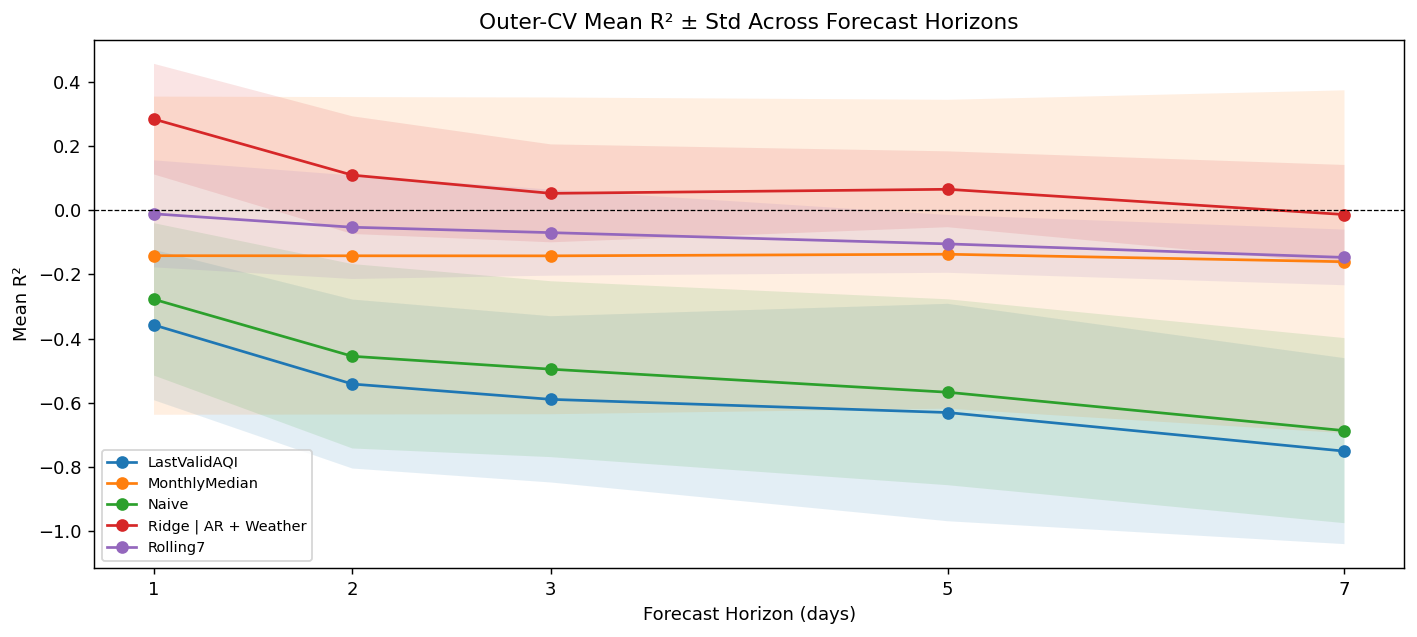

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
for model_name, grp in cv_summary.groupby("model"):
    ax.plot(grp["horizon"], grp["R2_mean"], marker="o", label=model_name)
    ax.fill_between(grp["horizon"],
                    grp["R2_mean"] - grp["R2_std"],
                    grp["R2_mean"] + grp["R2_std"], alpha=0.12)
ax.set_title("Outer-CV Mean R² ± Std Across Forecast Horizons")
ax.set_xlabel("Forecast Horizon (days)"); ax.set_ylabel("Mean R²")
ax.set_xticks(HORIZONS)
ax.axhline(0, color="k", linewidth=0.7, linestyle="--")
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show(fig, "04_cv_r2_across_horizons.png")

## 16. Holdout Regression – All Models (Tuned Hyperparameters)

In [18]:
h1_bundle = supervised_cache[PRIMARY_HORIZON]
engineered_1     = h1_bundle["engineered"]
feature_groups_1 = h1_bundle["feature_groups"]
feature_set_map_1= h1_bundle["feature_set_map"]
selected_cols_1  = h1_bundle["selected_cols"]
supervised_1     = h1_bundle["supervised"]

train_1, gap_1, test_1 = chronological_holdout_split(
    supervised_1, horizon=PRIMARY_HORIZON)

X_train_1    = train_1[selected_cols_1].to_numpy()
y_train_1    = train_1["target"].to_numpy()
X_test_1     = test_1[selected_cols_1].to_numpy()
y_test_1_raw = test_1["target_raw"].to_numpy()

holdout_regression_records = {}
holdout_regression_predictions = {}
holdout_regression_models = {}

for model_name in REGRESSION_MODEL_NAMES:
    m = fit_regression_model(model_name, train_1, X_train_1, y_train_1, PRIMARY_HORIZON)
    pred = predict_regression_raw(m, X_test_1)
    holdout_regression_models[model_name]      = m
    holdout_regression_predictions[model_name] = pred
    holdout_regression_records[model_name]     = regression_metrics(y_test_1_raw, pred)

for bname, bpred in baseline_predictions(train_1, test_1).items():
    holdout_regression_predictions[bname] = bpred
    holdout_regression_records[bname]     = regression_metrics(y_test_1_raw, bpred)

holdout_regression_results = (
    pd.DataFrame([{"model": k, **v} for k, v in holdout_regression_records.items()])
    .sort_values(["R2","MAE"], ascending=[False,True])
    .reset_index(drop=True)
)

holdout_regression_results.to_csv(TABLE_DIR / "holdout_regression_results_h1.csv", index=False)

print(f"Train rows: {len(train_1)}  Test rows: {len(test_1)}  Gap: {len(gap_1)}")
print()
print(holdout_regression_results.round(3).to_string(index=False))

Train rows: 1706  Test rows: 427  Gap: 1

               model    MAE   RMSE     R2  MedAE
               Ridge 15.312 20.765  0.487 11.599
        RandomForest 14.894 21.150  0.468 10.273
HistGradientBoosting 15.074 21.665  0.441 10.713
       WeightedRidge 19.597 27.149  0.123 13.868
            Rolling7 18.824 27.214  0.119 11.829
       MonthlyMedian 21.301 29.072 -0.006 15.500
               Naive 20.952 30.625 -0.116 12.000
        LastValidAQI 21.281 31.157 -0.155 12.000


## 17. Final Model Selection and Diebold–Mariano Significance Test

The DM test (Harvey-Leybourne-Newbold modified) tests H₀: equal MAE between the selected model and each competitor. Positive `mean_diff` means the competitor has higher MAE (is worse). p<0.05 indicates statistically significant difference.

In [19]:
final_regression_model = holdout_regression_models[final_regression_model_name]
final_pred_h1          = holdout_regression_predictions[final_regression_model_name]
final_holdout_metrics  = holdout_regression_records[final_regression_model_name]

print(f"Model : {final_regression_model_name}")
print(f"Features: {final_feature_set_name}  ({len(selected_cols_1)} columns)")
print(pd.Series(final_holdout_metrics).round(3).to_string())

dm_records = []
for competitor, pred in holdout_regression_predictions.items():
    if competitor == final_regression_model_name:
        continue
    dm = diebold_mariano_test(y_test_1_raw, pred, final_pred_h1)
    dm_records.append({
        "vs_model":  competitor,
        "mean_diff_mae": round(dm["mean_diff"], 4),
        "t_stat":    round(dm["t_stat"], 3)  if not np.isnan(dm["t_stat"])  else np.nan,
        "p_value":   round(dm["p_value"], 4) if not np.isnan(dm["p_value"]) else np.nan,
        "significant_5pct": "YES" if (not np.isnan(dm.get("p_value", np.nan))
                                      and dm["p_value"] < 0.05) else "NO",
    })

dm_table = pd.DataFrame(dm_records)
dm_table.to_csv(TABLE_DIR / "diebold_mariano_test_h1.csv", index=False)

print()
print("=== Diebold–Mariano Test (selected model vs. each competitor) ===")
print("mean_diff_mae > 0 means competitor is worse (higher MAE)")
print(dm_table.to_string(index=False))

Model : Ridge
Features: AR + Weather  (96 columns)
MAE      15.312
RMSE     20.765
R2        0.487
MedAE    11.599

=== Diebold–Mariano Test (selected model vs. each competitor) ===
mean_diff_mae > 0 means competitor is worse (higher MAE)
            vs_model  mean_diff_mae  t_stat  p_value significant_5pct
       WeightedRidge         4.2847   7.417   0.0000              YES
        RandomForest        -0.4177  -0.803   0.4223               NO
HistGradientBoosting        -0.2381  -0.491   0.6234               NO
               Naive         5.6402   6.096   0.0000              YES
            Rolling7         3.5123   3.982   0.0001              YES
        LastValidAQI         5.9692   6.188   0.0000              YES
       MonthlyMedian         5.9891   6.504   0.0000              YES


## 18. Weather-Input Availability Sensitivity

In [20]:
sensitivity_records = []
for mode in ["observed_same_day", "lagged_only"]:
    eng_m, fg_m, fsm_m, sup_m = prepare_supervised(df, horizon=PRIMARY_HORIZON, weather_mode=mode)
    sel_m = fsm_m[final_feature_set_name]
    tr_m, _, te_m = chronological_holdout_split(sup_m, horizon=PRIMARY_HORIZON)
    m = fit_regression_model(final_regression_model_name, tr_m,
                              tr_m[sel_m].to_numpy(), tr_m["target"].to_numpy(), PRIMARY_HORIZON)
    pred = predict_regression_raw(m, te_m[sel_m].to_numpy())
    sensitivity_records.append({"weather_mode": mode,
                                  **regression_metrics(te_m["target_raw"].to_numpy(), pred)})

weather_mode_comparison = (pd.DataFrame(sensitivity_records)
                            .sort_values("R2", ascending=False))
weather_mode_comparison.to_csv(TABLE_DIR / "weather_mode_sensitivity_h1.csv", index=False)
print(weather_mode_comparison.round(3).to_string(index=False))

     weather_mode    MAE   RMSE    R2  MedAE
observed_same_day 15.312 20.765 0.487 11.599
      lagged_only 16.106 22.168 0.415 12.074


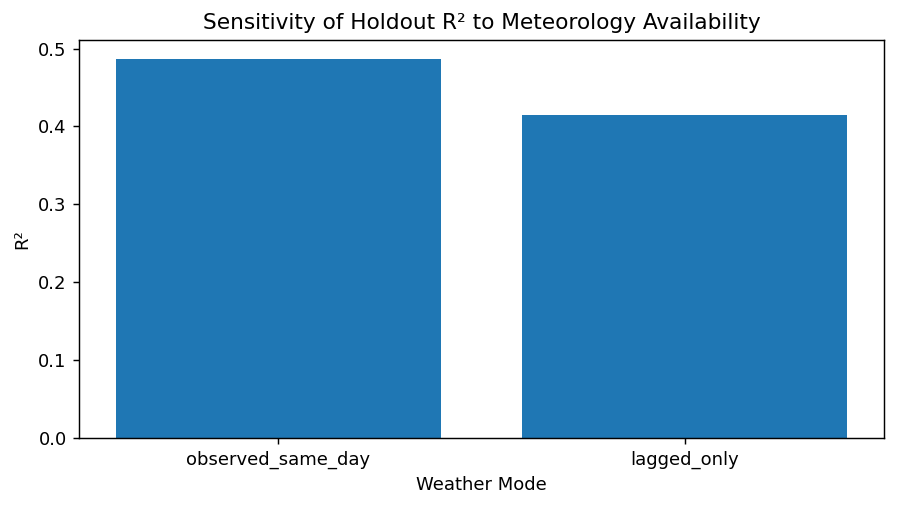

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(weather_mode_comparison["weather_mode"], weather_mode_comparison["R2"])
ax.set_title("Sensitivity of Holdout R² to Meteorology Availability")
ax.set_xlabel("Weather Mode"); ax.set_ylabel("R²")
fig.tight_layout()
save_and_show(fig, "05_weather_mode_sensitivity_r2.png")

## 19. Co-Pollutant Extension

In [22]:
copollutant_extension_records = []

if feature_groups_1["CoPollutants"]:
    ext_cols = unique_in_order(selected_cols_1 + feature_groups_1["CoPollutants"])
    for fold_id, (tr_idx, te_idx) in enumerate(
            make_purged_splits(supervised_1, n_splits=OUTER_SPLITS, horizon=PRIMARY_HORIZON), start=1):
        tr = supervised_1.iloc[tr_idx].copy().reset_index(drop=True)
        te = supervised_1.iloc[te_idx].copy().reset_index(drop=True)
        for setup, cols in [("Base", selected_cols_1), ("Base + CoPollutants", ext_cols)]:
            m = fit_regression_model(final_regression_model_name, tr,
                                      tr[cols].to_numpy(), tr["target"].to_numpy(), PRIMARY_HORIZON)
            pred = predict_regression_raw(m, te[cols].to_numpy())
            copollutant_extension_records.append({"fold": fold_id, "setup": setup,
                                                   **regression_metrics(te["target_raw"].to_numpy(), pred)})

copollutant_extension_results = pd.DataFrame(copollutant_extension_records)
copollutant_extension_summary = (
    copollutant_extension_results.groupby("setup")
    .agg(MAE_mean=("MAE","mean"), MAE_std=("MAE","std"),
         RMSE_mean=("RMSE","mean"), RMSE_std=("RMSE","std"),
         R2_mean=("R2","mean"), R2_std=("R2","std"))
    .reset_index().sort_values("R2_mean", ascending=False)
) if not copollutant_extension_results.empty else pd.DataFrame()

copollutant_holdout_results = []
if feature_groups_1["CoPollutants"]:
    ext_cols = unique_in_order(selected_cols_1 + feature_groups_1["CoPollutants"])
    for setup, cols in [("Base", selected_cols_1), ("Base + CoPollutants", ext_cols)]:
        m = fit_regression_model(final_regression_model_name, train_1,
                                  train_1[cols].to_numpy(), y_train_1, PRIMARY_HORIZON)
        pred = predict_regression_raw(m, test_1[cols].to_numpy())
        copollutant_holdout_results.append({"setup": setup,
                                             **regression_metrics(y_test_1_raw, pred)})

copollutant_holdout_df = (pd.DataFrame(copollutant_holdout_results)
                           .sort_values("R2", ascending=False).reset_index(drop=True))

copollutant_extension_results.to_csv(TABLE_DIR / "copollutant_extension_cv_fold_results_h1.csv", index=False)
copollutant_extension_summary.to_csv(TABLE_DIR / "copollutant_extension_cv_summary_h1.csv", index=False)
copollutant_holdout_df.to_csv(TABLE_DIR / "copollutant_extension_holdout_results_h1.csv", index=False)

print("=== CV Summary ===")
print(copollutant_extension_summary.round(3).to_string(index=False) if not copollutant_extension_summary.empty else "N/A")
print()
print("=== Holdout ===")
print(copollutant_holdout_df.round(3).to_string(index=False) if copollutant_holdout_df.size else "N/A")

=== CV Summary ===
              setup  MAE_mean  MAE_std  RMSE_mean  RMSE_std  R2_mean  R2_std
Base + CoPollutants    17.268    4.833     25.881     7.970    0.388   0.266
               Base    19.252    4.281     28.680     7.977    0.284   0.172

=== Holdout ===
              setup    MAE   RMSE    R2  MedAE
               Base 15.312 20.765 0.487 11.599
Base + CoPollutants 13.557 20.816 0.484  8.603


## 20. Co-Pollutant Covariate Shift Diagnosis

The co-pollutant block improves CV R² but degrades holdout R². Root cause: systematic missingness regime change between train and test. Median imputation in training learns incorrect fill values for near-zero-missing test data.

In [23]:
cov_shift = pd.DataFrame([
    {"co_pollutant": col,
     "train_miss_pct": round(100*df_train_raw[col].isna().mean(), 1),
     "test_miss_pct":  round(100*df_test_raw[col].isna().mean(),  1),
     "delta_miss_pct": round(100*df_test_raw[col].isna().mean() -
                              100*df_train_raw[col].isna().mean(), 1)}
    for col in AVAILABLE_COPOLLUTANT_COLS
])

cov_shift.to_csv(TABLE_DIR / "copollutant_covariate_shift.csv", index=False)
print("Co-pollutant missingness shift (train → test):")
print(cov_shift.to_string(index=False))
print()
print("Interpretation: NO2/SO2/CO switch from ~50% missing (imputed with median)")
print("in training to <4% in holdout. The imputer cannot generalize.")
print("Recommendation: co-pollutant block is valid for same-era data only.")

Co-pollutant missingness shift (train → test):
co_pollutant  train_miss_pct  test_miss_pct  delta_miss_pct
        pm10            41.1           67.7            26.6
         no2            58.0            3.4           -54.7
         so2            47.2            1.1           -46.2
          co            39.8            0.9           -38.9

Interpretation: NO2/SO2/CO switch from ~50% missing (imputed with median)
in training to <4% in holdout. The imputer cannot generalize.
Recommendation: co-pollutant block is valid for same-era data only.


## 21. Polluted-Day Detection – Outer Cross-Validation

'Tuned' means both hyperparameters (inner CV) and decision threshold (calibration-subset F1 maximisation) are optimised.

In [24]:
event_cv_records = []

for fold_id, (tr_idx, te_idx) in enumerate(
        make_purged_splits(supervised_1, n_splits=OUTER_SPLITS, horizon=PRIMARY_HORIZON), start=1):

    tr_full = supervised_1.iloc[tr_idx].copy().reset_index(drop=True)
    te      = supervised_1.iloc[te_idx].copy().reset_index(drop=True)
    proper_tr, calib_df = chronological_calibration_split(tr_full)

    X_ptr, y_ptr_log = proper_tr[selected_cols_1].to_numpy(), proper_tr["target"].to_numpy()
    X_cal, y_cal_bin = calib_df[selected_cols_1].to_numpy(), calib_df["event_target_100"].to_numpy()
    X_trf, y_trf_log = tr_full[selected_cols_1].to_numpy(), tr_full["target"].to_numpy()
    X_te,  y_te_bin  = te[selected_cols_1].to_numpy(), te["event_target_100"].to_numpy()

    reg_tune_m = fit_regression_model(final_regression_model_name, proper_tr,
                                       X_ptr, y_ptr_log, PRIMARY_HORIZON)
    reg_cal_sc = predict_regression_raw(reg_tune_m, X_cal)

    thr_grid = np.linspace(40.0, 160.0, 241)
    if np.unique(y_cal_bin).size < 2:
        reg_thr = EVENT_THRESHOLD_PRIMARY
    else:
        reg_thr = choose_best_threshold(threshold_search(y_cal_bin, reg_cal_sc, thr_grid),
                                        EVENT_THRESHOLD_PRIMARY)

    reg_full_m = fit_regression_model(final_regression_model_name, tr_full,
                                       X_trf, y_trf_log, PRIMARY_HORIZON)
    reg_sc_te  = predict_regression_raw(reg_full_m, X_te)

    event_cv_records.append({"fold": fold_id, "approach": "Regression@100",
                               **classification_metrics(y_te_bin, reg_sc_te, EVENT_THRESHOLD_PRIMARY)})
    event_cv_records.append({"fold": fold_id, "approach": "RegressionTuned",
                               **classification_metrics(y_te_bin, reg_sc_te, reg_thr)})

    if np.unique(proper_tr["event_target_100"]).size >= 2 and np.unique(tr_full["event_target_100"]).size >= 2:
        inner_cv = make_inner_cv(tr_full[[DATE_COL]].copy(), horizon=PRIMARY_HORIZON)
        for clf_name in CLASSIFICATION_MODEL_NAMES:
            clf_tune = fit_classification_model(clf_name, X_ptr,
                                                 proper_tr["event_target_100"].to_numpy(),
                                                 train_df=proper_tr, horizon=PRIMARY_HORIZON)
            clf_cal_sc = predict_positive_score(clf_tune, X_cal)
            clf_thr_grid = np.linspace(0.05, 0.95, 181)
            clf_thr = (choose_best_threshold(threshold_search(y_cal_bin, clf_cal_sc, clf_thr_grid), 0.50)
                       if np.unique(y_cal_bin).size >= 2 else 0.50)
            clf_full = fit_classification_model(clf_name, X_trf,
                                                 tr_full["event_target_100"].to_numpy(),
                                                 train_df=tr_full, horizon=PRIMARY_HORIZON)
            clf_sc_te = predict_positive_score(clf_full, X_te)
            event_cv_records.append({"fold": fold_id, "approach": f"{clf_name}Tuned",
                                      **classification_metrics(y_te_bin, clf_sc_te, clf_thr)})

event_cv_results  = pd.DataFrame(event_cv_records)
event_cv_summary  = (
    event_cv_results.groupby("approach")
    .agg(precision_mean=("precision","mean"), precision_std=("precision","std"),
         recall_mean=("recall","mean"),    recall_std=("recall","std"),
         f1_mean=("f1","mean"),            f1_std=("f1","std"),
         ap_mean=("average_precision","mean"), ap_std=("average_precision","std"),
         roc_auc_mean=("roc_auc","mean"),  roc_auc_std=("roc_auc","std"),
         threshold_mean=("threshold","mean"))
    .reset_index()
    .sort_values(["f1_mean","precision_mean"], ascending=[False,False])
)

event_cv_results.to_csv(TABLE_DIR / "event_cv_fold_results_h1.csv", index=False)
event_cv_summary.to_csv(TABLE_DIR / "event_cv_summary_h1.csv", index=False)

disp_cols = ["approach","precision_mean","precision_std","recall_mean","recall_std",
             "f1_mean","f1_std","ap_mean","roc_auc_mean","threshold_mean"]
print(event_cv_summary[disp_cols].round(3).to_string(index=False))

                           approach  precision_mean  precision_std  recall_mean  recall_std  f1_mean  f1_std  ap_mean  roc_auc_mean  threshold_mean
HistGradientBoostingClassifierTuned           0.317          0.216        0.586       0.348    0.358   0.206    0.378         0.836           0.189
        RandomForestClassifierTuned           0.269          0.147        0.600       0.316    0.351   0.169    0.376         0.845           0.312
                      LogisticTuned           0.275          0.162        0.515       0.302    0.297   0.110    0.374         0.809           0.511
                    RegressionTuned           0.243          0.193        0.551       0.385    0.294   0.187    0.381         0.841          73.700
                     Regression@100           0.488          0.358        0.242       0.177    0.290   0.176    0.381         0.841         100.000


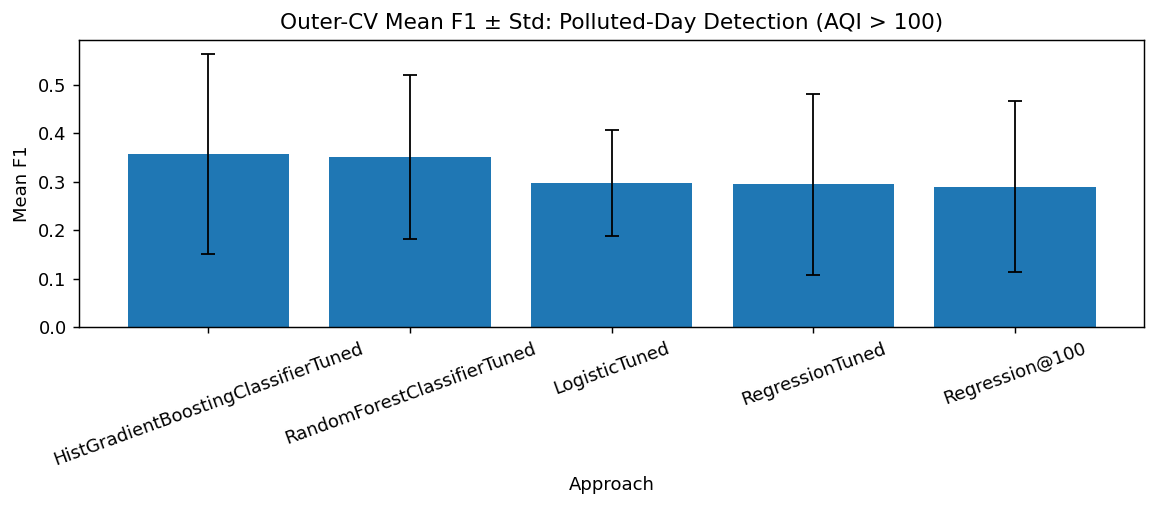

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = event_cv_summary.sort_values("f1_mean", ascending=False)
ax.bar(plot_df["approach"], plot_df["f1_mean"], yerr=plot_df["f1_std"],
       capsize=4, error_kw={"elinewidth": 1})
ax.set_title("Outer-CV Mean F1 ± Std: Polluted-Day Detection (AQI > 100)")
ax.set_xlabel("Approach"); ax.set_ylabel("Mean F1")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
save_and_show(fig, "07_event_cv_f1_comparison_h1.png")

## 22. Polluted-Day Detection – Holdout

In [26]:
best_cv_event       = event_cv_summary.iloc[0]["approach"]
clf_rows            = event_cv_summary[event_cv_summary["approach"].str.contains("Tuned") &
                                       ~event_cv_summary["approach"].str.startswith("Regression")]
best_classifier_cv  = clf_rows.iloc[0]["approach"] if not clf_rows.empty else None

event_train, event_calib = chronological_calibration_split(train_1)

X_etr = event_train[selected_cols_1].to_numpy()
y_etr_log, y_etr_bin = event_train["target"].to_numpy(), event_train["event_target_100"].to_numpy()
X_ecal, y_ecal_bin   = event_calib[selected_cols_1].to_numpy(), event_calib["event_target_100"].to_numpy()
X_ete, y_ete_bin     = test_1[selected_cols_1].to_numpy(), test_1["event_target_100"].to_numpy()

reg_etune = fit_regression_model(final_regression_model_name, event_train,
                                  X_etr, y_etr_log, PRIMARY_HORIZON)
reg_ecal_sc   = predict_regression_raw(reg_etune, X_ecal)
thr_grid      = np.linspace(40.0, 160.0, 241)
reg_best_thr  = (choose_best_threshold(threshold_search(y_ecal_bin, reg_ecal_sc, thr_grid),
                                       EVENT_THRESHOLD_PRIMARY)
                 if np.unique(y_ecal_bin).size >= 2 else EVENT_THRESHOLD_PRIMARY)

reg_efull  = fit_regression_model(final_regression_model_name, train_1,
                                   X_train_1, y_train_1, PRIMARY_HORIZON)
reg_esc_te = predict_regression_raw(reg_efull, X_ete)

event_holdout_records, event_score_store, event_pred_store, event_thr_store = {}, {}, {}, {}

for approach, thr in [("Regression@100", EVENT_THRESHOLD_PRIMARY), ("RegressionTuned", reg_best_thr)]:
    m_cl = classification_metrics(y_ete_bin, reg_esc_te, thr)
    event_holdout_records[approach] = m_cl
    event_score_store[approach]     = reg_esc_te
    event_pred_store[approach]      = (reg_esc_te >= thr).astype(int)
    event_thr_store[approach]       = thr

if np.unique(y_etr_bin).size >= 2:
    for clf_name in CLASSIFICATION_MODEL_NAMES:
        clf_tune = fit_classification_model(clf_name, X_etr, y_etr_bin,
                                             train_df=event_train, horizon=PRIMARY_HORIZON)
        clf_cal_sc   = predict_positive_score(clf_tune, X_ecal)
        clf_thr_grid = np.linspace(0.05, 0.95, 181)
        clf_best_thr = (choose_best_threshold(threshold_search(y_ecal_bin, clf_cal_sc, clf_thr_grid), 0.50)
                        if np.unique(y_ecal_bin).size >= 2 else 0.50)
        clf_full = fit_classification_model(clf_name, X_train_1,
                                             train_1["event_target_100"].to_numpy(),
                                             train_df=train_1, horizon=PRIMARY_HORIZON)
        clf_sc_te = predict_positive_score(clf_full, X_ete)
        approach  = f"{clf_name}Tuned"
        event_holdout_records[approach] = classification_metrics(y_ete_bin, clf_sc_te, clf_best_thr)
        event_score_store[approach]     = clf_sc_te
        event_pred_store[approach]      = (clf_sc_te >= clf_best_thr).astype(int)
        event_thr_store[approach]       = clf_best_thr

event_holdout_df = (
    pd.DataFrame([{"approach": k, **v} for k, v in event_holdout_records.items()])
    .sort_values(["f1","precision"], ascending=[False,False])
    .reset_index(drop=True)
)

event_holdout_df.to_csv(TABLE_DIR / "event_holdout_results_h1.csv", index=False)
print(event_holdout_df[["approach","precision","recall","f1","average_precision","roc_auc","threshold"]]
      .round(3).to_string(index=False))

best_holdout_event = event_holdout_df.iloc[0]["approach"]
print(f"\nBest holdout approach: {best_holdout_event}  "
      f"(threshold={event_thr_store[best_holdout_event]:.1f})")

                           approach  precision  recall    f1  average_precision  roc_auc  threshold
                     Regression@100      0.436   0.405 0.420              0.462    0.916    100.000
                    RegressionTuned      0.429   0.357 0.390              0.462    0.916    102.000
HistGradientBoostingClassifierTuned      0.371   0.310 0.338              0.371    0.878      0.565
                      LogisticTuned      0.316   0.286 0.300              0.295    0.860      0.915
        RandomForestClassifierTuned      0.467   0.167 0.246              0.419    0.890      0.575

Best holdout approach: Regression@100  (threshold=100.0)


## 23. Precision–Recall Curves

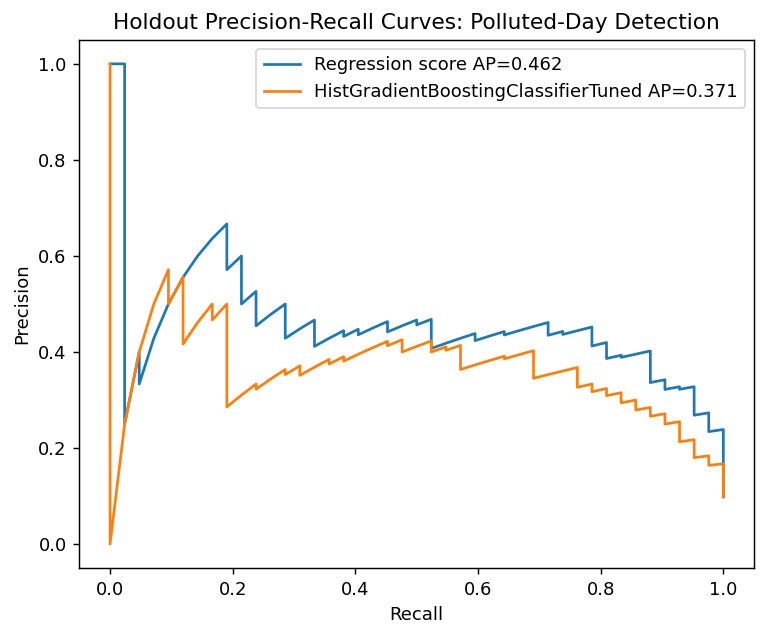

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
reg_p, reg_r, _ = precision_recall_curve(y_ete_bin, event_score_store["RegressionTuned"])
reg_ap = safe_average_precision(y_ete_bin, event_score_store["RegressionTuned"])
ax.plot(reg_r, reg_p, label=f"Regression score AP={reg_ap:.3f}")

if best_classifier_cv is not None and best_classifier_cv in event_score_store:
    clf_p, clf_r, _ = precision_recall_curve(y_ete_bin, event_score_store[best_classifier_cv])
    clf_ap = safe_average_precision(y_ete_bin, event_score_store[best_classifier_cv])
    ax.plot(clf_r, clf_p, label=f"{best_classifier_cv} AP={clf_ap:.3f}")

ax.set_title("Holdout Precision-Recall Curves: Polluted-Day Detection")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend()
fig.tight_layout()
save_and_show(fig, "08_event_pr_curves_h1.png")

## 24. Holdout Actual vs Predicted

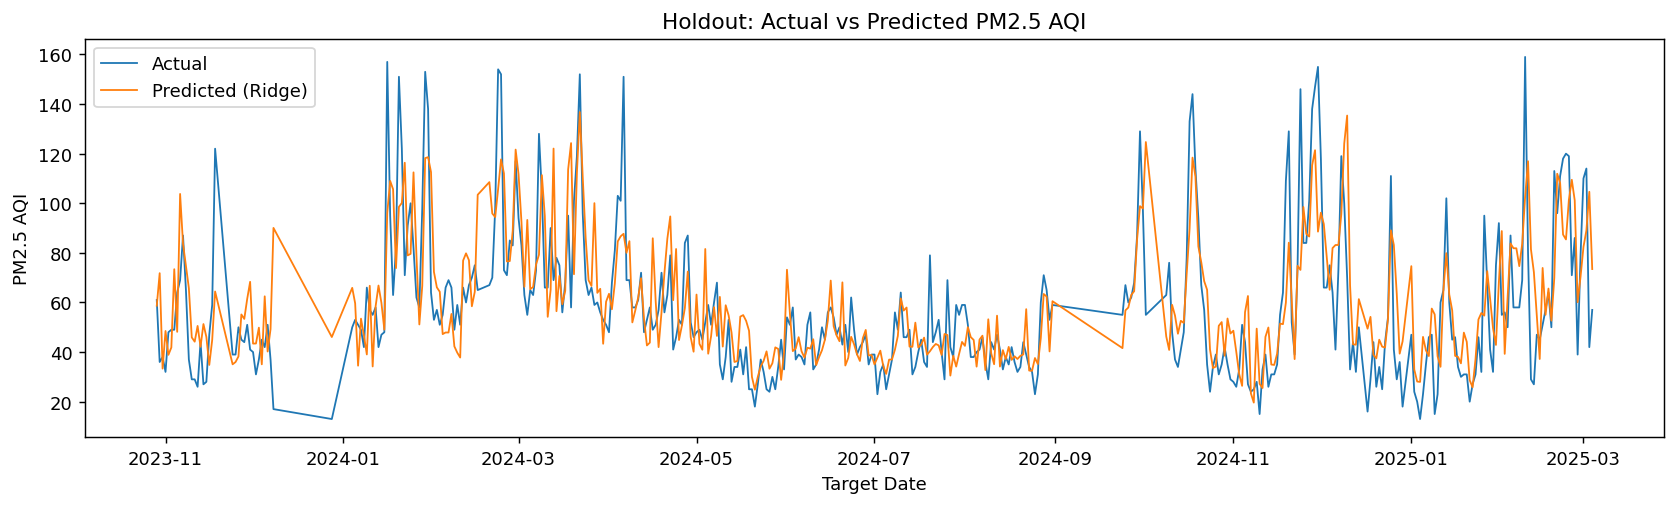

In [28]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_1["target_date"], y_test_1_raw, label="Actual", linewidth=1)
ax.plot(test_1["target_date"], final_pred_h1,
        label=f"Predicted ({final_regression_model_name})", linewidth=1)
ax.set_title("Holdout: Actual vs Predicted PM2.5 AQI")
ax.set_xlabel("Target Date"); ax.set_ylabel("PM2.5 AQI")
ax.legend()
fig.tight_layout()
save_and_show(fig, "10_holdout_actual_vs_predicted_h1.png")

## 25. Error Analysis

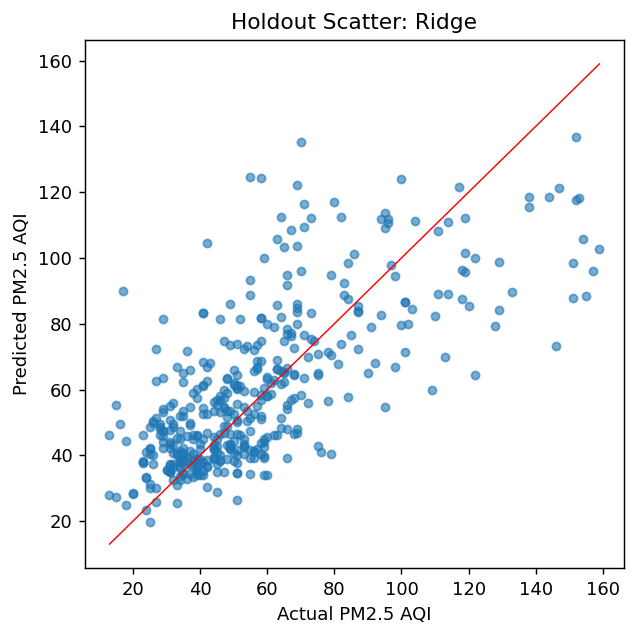

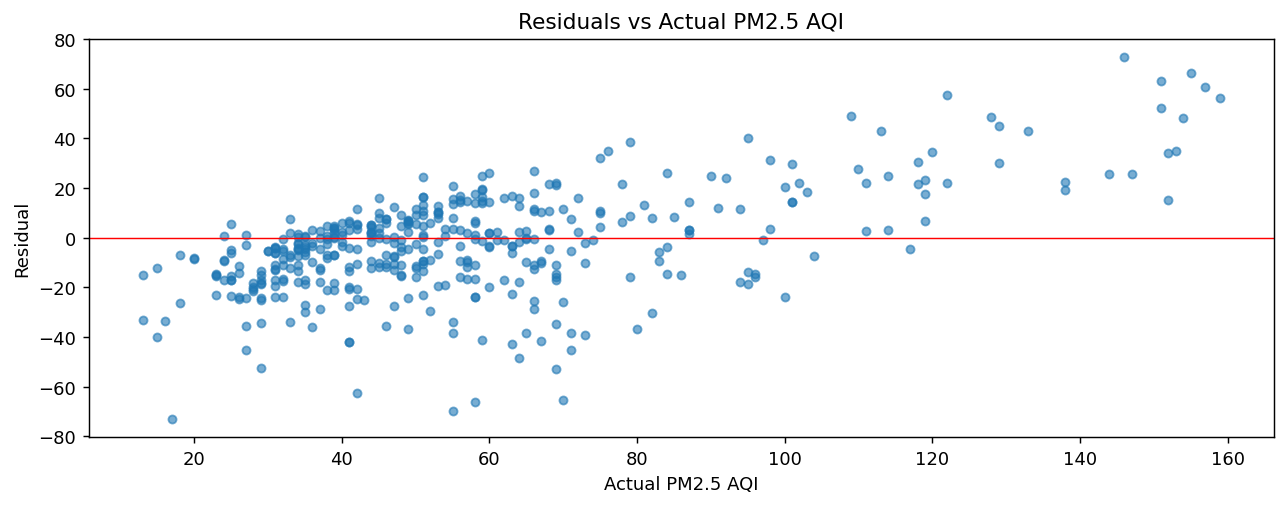

In [29]:
error_table = test_1[[DATE_COL,"target_date"]].copy()
error_table["actual_pm25_aqi"] = y_test_1_raw
error_table["pred_pm25_aqi"]   = final_pred_h1
error_table["residual"]        = error_table["actual_pm25_aqi"] - error_table["pred_pm25_aqi"]
error_table["abs_error"]       = np.abs(error_table["residual"])
error_table["actual_category"] = aqi_category(error_table["actual_pm25_aqi"]).values
error_table["pred_category"]   = aqi_category(error_table["pred_pm25_aqi"]).values
error_table.to_csv(TABLE_DIR / "holdout_error_table_h1.csv", index=False)

fig, ax = plt.subplots(figsize=(5, 5))
mn = min(error_table["actual_pm25_aqi"].min(), error_table["pred_pm25_aqi"].min())
mx = max(error_table["actual_pm25_aqi"].max(), error_table["pred_pm25_aqi"].max())
ax.scatter(error_table["actual_pm25_aqi"], error_table["pred_pm25_aqi"], alpha=0.6, s=20)
ax.plot([mn, mx], [mn, mx], color="r", linewidth=0.8)
ax.set_title(f"Holdout Scatter: {final_regression_model_name}")
ax.set_xlabel("Actual PM2.5 AQI"); ax.set_ylabel("Predicted PM2.5 AQI")
fig.tight_layout()
save_and_show(fig, "11_holdout_scatter_h1.png")

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(error_table["actual_pm25_aqi"], error_table["residual"], alpha=0.6, s=20)
ax.axhline(0, color="r", linewidth=0.8)
ax.set_title("Residuals vs Actual PM2.5 AQI")
ax.set_xlabel("Actual PM2.5 AQI"); ax.set_ylabel("Residual")
fig.tight_layout()
save_and_show(fig, "12_residuals_vs_actual_h1.png")

## 26. Feature-Set Ablation (Holdout)

In [30]:
ablation_records = []
for set_name, cols in make_feature_set_map(feature_groups_1).items():
    m = fit_regression_model(final_regression_model_name, train_1,
                              train_1[cols].to_numpy(), y_train_1, PRIMARY_HORIZON)
    pred = predict_regression_raw(m, test_1[cols].to_numpy())
    ablation_records.append({"feature_set": set_name, "n_features": len(cols),
                               **regression_metrics(y_test_1_raw, pred)})

ablation_results = (pd.DataFrame(ablation_records)
                    .sort_values(["R2","MAE"], ascending=[False,True])
                    .reset_index(drop=True))
ablation_results.to_csv(TABLE_DIR / "ablation_results_h1.csv", index=False)
print(ablation_results.round(3).to_string(index=False))

  feature_set  n_features    MAE   RMSE    R2  MedAE
 AR + Weather          96 15.312 20.765 0.487 11.599
 Weather only          76 15.854 20.902 0.480 12.350
         Full         100 15.529 21.021 0.474 11.948
AR + Calendar          24 17.795 24.646 0.277 13.513
      AR only          20 17.204 25.532 0.224 11.361


## 27. Permutation Importance

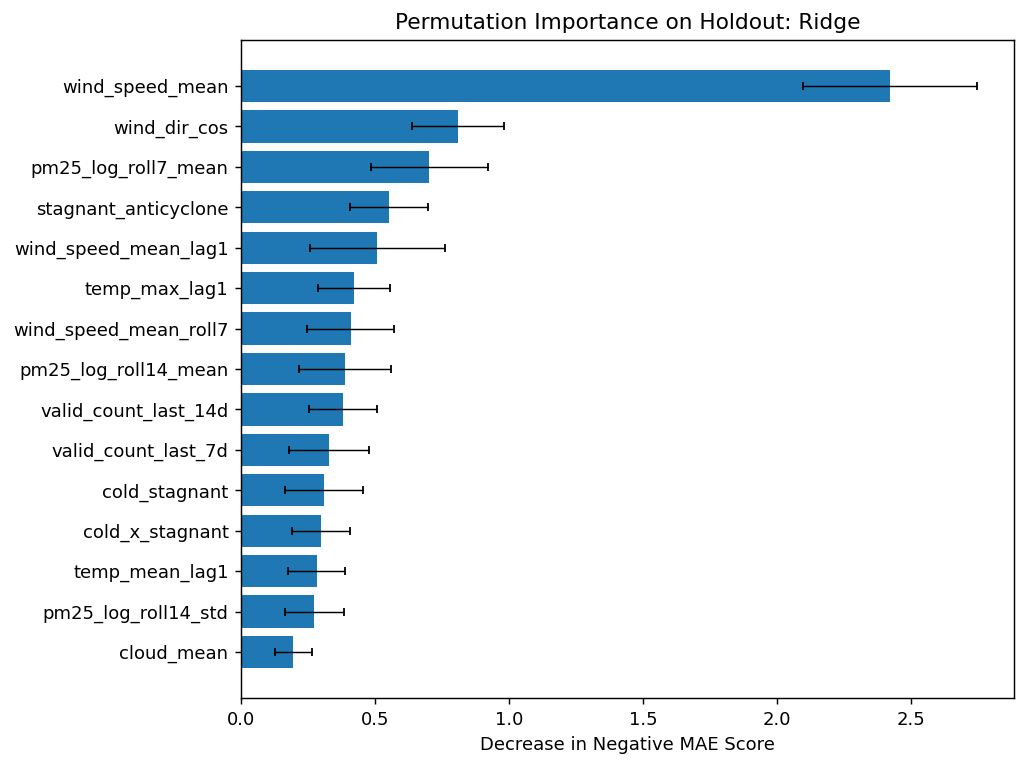

              feature  importance_mean  importance_std
      wind_speed_mean           2.4214          0.3251
         wind_dir_cos           0.8094          0.1732
  pm25_log_roll7_mean           0.7027          0.2167
 stagnant_anticyclone           0.5524          0.1446
 wind_speed_mean_lag1           0.5082          0.2526
        temp_max_lag1           0.4226          0.1342
wind_speed_mean_roll7           0.4086          0.1619
 pm25_log_roll14_mean           0.3873          0.1702
 valid_count_last_14d           0.3798          0.1257
  valid_count_last_7d           0.3271          0.1497
        cold_stagnant           0.3094          0.1453
      cold_x_stagnant           0.2986          0.1093
       temp_mean_lag1           0.2822          0.1069
  pm25_log_roll14_std           0.2733          0.1094
           cloud_mean           0.1938          0.0692
        pm25_log_lag2           0.1919          0.1180
        pm25_log_lag1           0.1683          0.1204
  dew_poin

In [31]:
perm_result = permutation_importance(
    final_regression_model, X_test_1, test_1["target"].to_numpy(),
    n_repeats=20, random_state=RANDOM_SEED, scoring=raw_neg_mae_scorer, n_jobs=-1,
)

perm_table = (pd.DataFrame({
    "feature":          selected_cols_1,
    "importance_mean":  perm_result.importances_mean,
    "importance_std":   perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True))

perm_table.to_csv(TABLE_DIR / "permutation_importance_h1.csv", index=False)

top_p = perm_table.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_p["feature"], top_p["importance_mean"],
        xerr=top_p["importance_std"], capsize=2, error_kw={"elinewidth":0.8})
ax.set_title(f"Permutation Importance on Holdout: {final_regression_model_name}")
ax.set_xlabel("Decrease in Negative MAE Score")
fig.tight_layout()
save_and_show(fig, "13_permutation_importance_h1.png")
print(perm_table.head(20).round(4).to_string(index=False))

## 28. Cross-Conformal (CV+) Prediction Intervals

Replaces split-conformal with cross-conformal: all training rows are used as calibration data via K-fold leave-one-fold-out residuals. This resolves the under-coverage in the high-AQI regime by providing substantially more calibration residuals (especially for high-AQI regimes).

In [32]:
cv_plus_splits = make_purged_splits(train_1, n_splits=CV_PLUS_SPLITS, horizon=PRIMARY_HORIZON)

calib_preds_all = []
calib_true_all  = []

for tr_idx, va_idx in cv_plus_splits:
    tr_cv = train_1.iloc[tr_idx].copy().reset_index(drop=True)
    va_cv = train_1.iloc[va_idx].copy().reset_index(drop=True)

    m_cv  = fit_regression_model(final_regression_model_name, tr_cv,
                                  tr_cv[selected_cols_1].to_numpy(),
                                  tr_cv["target"].to_numpy(), PRIMARY_HORIZON)
    calib_preds_all.append(predict_regression_raw(m_cv, va_cv[selected_cols_1].to_numpy()))
    calib_true_all.append(va_cv["target_raw"].to_numpy())

calib_pred_cv  = np.concatenate(calib_preds_all)
calib_true_cv  = np.concatenate(calib_true_all)
calib_resid_cv = np.abs(calib_true_cv - calib_pred_cv)

q_level    = min(1.0, np.ceil((len(calib_resid_cv) + 1) * (1 - ALPHA_INTERVAL)) / len(calib_resid_cv))
global_qhat= float(np.quantile(calib_resid_cv, q_level))

calib_regime = (calib_pred_cv >= EVENT_THRESHOLD_PRIMARY).astype(int)
regime_qhats = {}
for regime in [0, 1]:
    mask = calib_regime == regime
    resid_r = calib_resid_cv[mask]
    if mask.sum() >= MIN_LOCAL_CONFORMAL_ROWS:
        q_r = min(1.0, np.ceil((len(resid_r) + 1) * (1 - ALPHA_INTERVAL)) / len(resid_r))
        regime_qhats[regime] = float(np.quantile(resid_r, q_r))
    else:
        regime_qhats[regime] = global_qhat

test_regime = (final_pred_h1 >= EVENT_THRESHOLD_PRIMARY).astype(int)
test_qhat   = np.where(test_regime == 1, regime_qhats[1], regime_qhats[0])
lower_cv    = np.clip(final_pred_h1 - test_qhat, 0.0, None)
upper_cv    = final_pred_h1 + test_qhat

coverage_overall = float(np.mean((y_test_1_raw >= lower_cv) & (y_test_1_raw <= upper_cv)))
coverage_low     = float(np.mean((y_test_1_raw[test_regime==0] >= lower_cv[test_regime==0]) &
                                  (y_test_1_raw[test_regime==0] <= upper_cv[test_regime==0])))                     if (test_regime==0).sum() > 0 else np.nan
coverage_high    = float(np.mean((y_test_1_raw[test_regime==1] >= lower_cv[test_regime==1]) &
                                  (y_test_1_raw[test_regime==1] <= upper_cv[test_regime==1])))                     if (test_regime==1).sum() > 0 else np.nan

cvplus_summary = pd.Series({
    "method":                         "cross-conformal (CV+)",
    "cv_plus_splits":                  CV_PLUS_SPLITS,
    "calibration_residuals":           len(calib_resid_cv),
    "nominal_coverage":                1 - ALPHA_INTERVAL,
    "empirical_coverage_overall":      round(coverage_overall, 3),
    "empirical_coverage_pred_low":     round(coverage_low,     3) if not np.isnan(coverage_low)  else np.nan,
    "empirical_coverage_pred_high":    round(coverage_high,    3) if not np.isnan(coverage_high) else np.nan,
    "average_interval_width":          round(np.mean(upper_cv - lower_cv), 3),
    "global_qhat":                     round(global_qhat, 3),
    "qhat_pred_low_regime":            round(regime_qhats[0], 3),
    "qhat_pred_high_regime":           round(regime_qhats[1], 3),
    "n_test_high_regime":              int((test_regime==1).sum()),
})
cvplus_summary.to_csv(TABLE_DIR / "cvplus_uncertainty_summary_h1.csv")
print(cvplus_summary.to_string())

method                          cross-conformal (CV+)
cv_plus_splits                                      5
calibration_residuals                            1420
nominal_coverage                                  0.9
empirical_coverage_overall                      0.963
empirical_coverage_pred_low                     0.959
empirical_coverage_pred_high                      1.0
average_interval_width                         94.617
global_qhat                                     46.34
qhat_pred_low_regime                           42.136
qhat_pred_high_regime                         108.026
n_test_high_regime                                 39


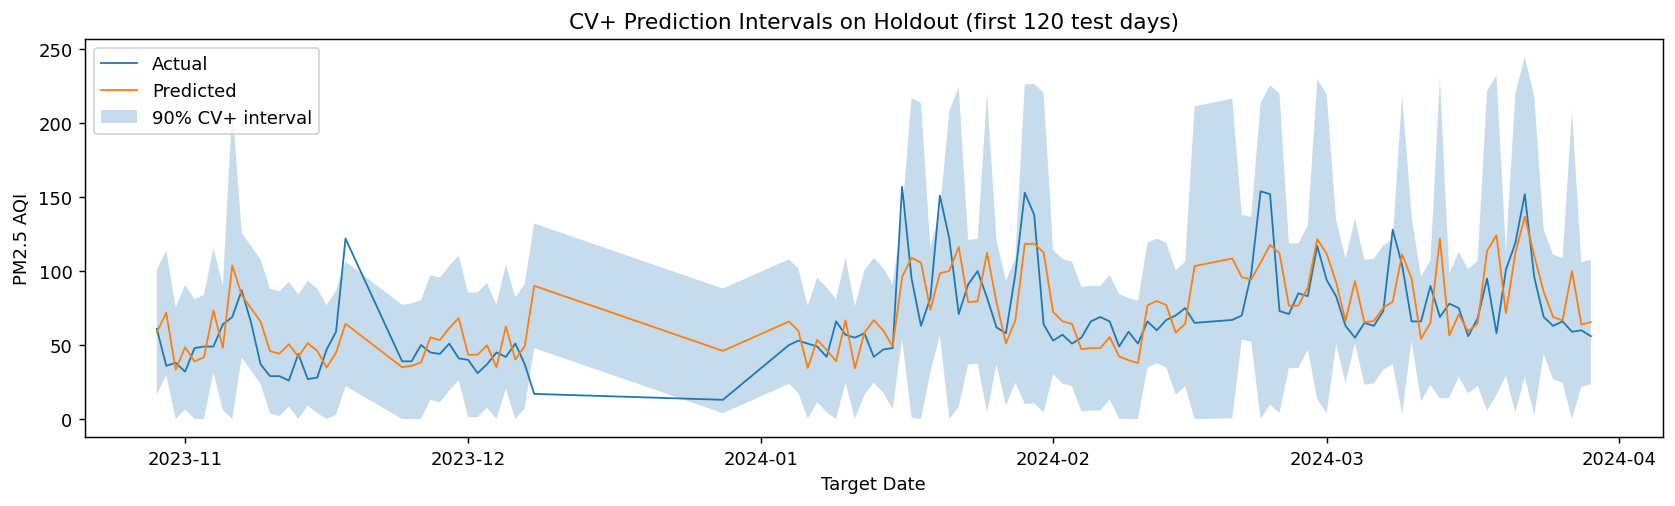

In [33]:
interval_plot_df = pd.DataFrame({
    "target_date":    test_1["target_date"].values,
    "actual":         y_test_1_raw,
    "predicted":      final_pred_h1,
    "lower":          lower_cv,
    "upper":          upper_cv,
})

subset = interval_plot_df.head(min(120, len(interval_plot_df)))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(subset["target_date"], subset["actual"],    label="Actual",    linewidth=1)
ax.plot(subset["target_date"], subset["predicted"], label="Predicted", linewidth=1)
ax.fill_between(subset["target_date"], subset["lower"], subset["upper"], alpha=0.25,
                label=f"90% CV+ interval")
ax.set_title("CV+ Prediction Intervals on Holdout (first 120 test days)")
ax.set_xlabel("Target Date"); ax.set_ylabel("PM2.5 AQI")
ax.legend()
fig.tight_layout()
save_and_show(fig, "14_prediction_intervals_h1.png")

## 29. Inference Example

In [34]:
full_model = fit_regression_model(
    final_regression_model_name, supervised_1,
    supervised_1[selected_cols_1].to_numpy(), supervised_1["target"].to_numpy(), PRIMARY_HORIZON,
)

latest_row  = engineered_1.sort_values(DATE_COL).iloc[[-1]].copy()
pred_raw    = float(predict_regression_raw(full_model, latest_row[selected_cols_1].to_numpy())[0])
pred_label  = aqi_category([pred_raw]).iloc[0]
pred_event  = int(pred_raw >= reg_best_thr)

inference_out = pd.Series({
    "issue_date":            latest_row[DATE_COL].iloc[0].date(),
    "forecast_target_date":  (latest_row[DATE_COL].iloc[0] + pd.Timedelta(days=1)).date(),
    "predicted_pm25_aqi":    round(pred_raw, 2),
    "predicted_aqi_category":pred_label,
    "event_threshold_used":  round(float(reg_best_thr), 1),
    "predicted_event_gt100": pred_event,
    "interval_lower":        round(float(max(0, pred_raw - regime_qhats[int(pred_raw >= EVENT_THRESHOLD_PRIMARY)])), 1),
    "interval_upper":        round(float(pred_raw + regime_qhats[int(pred_raw >= EVENT_THRESHOLD_PRIMARY)]), 1),
})
print(inference_out.to_string())

issue_date                2026-03-08
forecast_target_date      2026-03-09
predicted_pm25_aqi             94.95
predicted_aqi_category      Moderate
event_threshold_used           102.0
predicted_event_gt100              0
interval_lower                  52.8
interval_upper                 137.1


## 30. Article-Ready Summary

In [35]:
dm_row_rf = dm_table[dm_table["vs_model"] == "RandomForest"].iloc[0] if "RandomForest" in dm_table["vs_model"].values else None
dm_p_vs_rf = round(dm_row_rf["p_value"], 4) if dm_row_rf is not None else np.nan

article_summary = pd.DataFrame([
    {"item": "Final regression model",            "value": final_regression_model_name},
    {"item": "Final feature set",                 "value": final_feature_set_name},
    {"item": "CV h=1 R2 mean ± std",
     "value": f"{cv_summary[(cv_summary.horizon==1) & (cv_summary.model.str.startswith(final_regression_model_name))]['R2_mean'].values[0]:.3f} ± "
               f"{cv_summary[(cv_summary.horizon==1) & (cv_summary.model.str.startswith(final_regression_model_name))]['R2_std'].values[0]:.3f}"},
    {"item": "Holdout MAE",                       "value": round(final_holdout_metrics["MAE"],  3)},
    {"item": "Holdout RMSE",                      "value": round(final_holdout_metrics["RMSE"], 3)},
    {"item": "Holdout R2",                        "value": round(final_holdout_metrics["R2"],   3)},
    {"item": "Holdout MedAE",                     "value": round(final_holdout_metrics["MedAE"],3)},
    {"item": "DM test p-value (vs RandomForest)", "value": dm_p_vs_rf},
    {"item": "Best CV event approach",            "value": best_cv_event},
    {"item": "Best holdout event approach",       "value": best_holdout_event},
    {"item": "Best holdout event F1",             "value": round(event_holdout_df.iloc[0]["f1"], 3)},
    {"item": "Best holdout event threshold",      "value": round(event_thr_store[best_holdout_event], 1)},
    {"item": "CV+ coverage overall",              "value": round(coverage_overall, 3)},
    {"item": "CV+ coverage high-AQI regime",      "value": round(coverage_high,   3) if not np.isnan(coverage_high) else "N/A"},
    {"item": "CV+ avg interval width (AQI)",      "value": round(float(np.mean(upper_cv - lower_cv)), 2)},
    {"item": "Train PM2.5 valid %",               "value": round(100*df_train_raw[TARGET_COL].notna().mean(), 1)},
    {"item": "Test PM2.5 valid %",                "value": round(100*df_test_raw[TARGET_COL].notna().mean(), 1)},
])

article_summary.to_csv(TABLE_DIR / "article_summary.csv", index=False)
print(article_summary.to_string(index=False))

                             item                               value
           Final regression model                               Ridge
                Final feature set                        AR + Weather
             CV h=1 R2 mean ± std                       0.284 ± 0.172
                      Holdout MAE                              15.312
                     Holdout RMSE                              20.765
                       Holdout R2                               0.487
                    Holdout MedAE                              11.599
DM test p-value (vs RandomForest)                              0.4223
           Best CV event approach HistGradientBoostingClassifierTuned
      Best holdout event approach                      Regression@100
            Best holdout event F1                                0.42
     Best holdout event threshold                               100.0
             CV+ coverage overall                               0.963
     CV+ coverage hi

## 31. Output File Index

In [36]:
print("=== FIGURES ===")
for p in sorted(FIG_DIR.glob("*.png")):
    print(p.name)

print()
print("=== TABLES ===")
for p in sorted(TABLE_DIR.glob("*.csv")):
    print(p.name)

=== FIGURES ===
01_daily_pm25_aqi_time_series.png
02_aqi_category_distribution.png
04_cv_r2_across_horizons.png
05_weather_mode_sensitivity_r2.png
07_event_cv_f1_comparison_h1.png
08_event_pr_curves_h1.png
10_holdout_actual_vs_predicted_h1.png
11_holdout_scatter_h1.png
12_residuals_vs_actual_h1.png
13_permutation_importance_h1.png
14_prediction_intervals_h1.png

=== TABLES ===
ablation_results_h1.csv
aqi_category_distribution.csv
article_summary.csv
copollutant_covariate_shift.csv
copollutant_extension_cv_fold_results_h1.csv
copollutant_extension_cv_summary_h1.csv
copollutant_extension_holdout_results_h1.csv
copollutant_missingness_by_split.csv
cv_fold_results.csv
cv_summary.csv
cvplus_uncertainty_summary_h1.csv
data_quality_summary.csv
diebold_mariano_test_h1.csv
event_cv_fold_results_h1.csv
event_cv_summary_h1.csv
event_holdout_results_h1.csv
holdout_error_table_h1.csv
holdout_regression_results_h1.csv
missingness_by_split.csv
permutation_importance_h1.csv
regression_feature_selectio